In [117]:
%pip install numpy pandas scipy matplotlib yfinance requests tqdm

# Note to future self - use openbb for transcript for the CNN

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Importing and Setting Up
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
import requests
import warnings
from io import StringIO
import re
from tqdm import tqdm
import time
from edgar import *

warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Pulling the current S&P 500 stocks, yes this is igroning Sirvivorship bias and etc
tickers = []
try:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status() 
    
    html_buffer = StringIO(response.text)
    df = pd.read_html(html_buffer, attrs={'id': 'constituents'})[0]
    
    tickers = df['Symbol'].tolist()
    tickers = [t.replace('.', '-') for t in tickers]
    print(f"Loaded {len(tickers)} tickers successfully.")

except Exception as e:
    print(f"yfinance tickers_sp500() failed: {e}")

Loaded 503 tickers successfully.


In [120]:
# Method used to find the change in prices from original to given number of days
def forward_return(price_df, event_date, days):
    try:
        # get_indexer with nearest handles matching the earnings timestamp to the daily price data
        idx = price_df.index.get_indexer([event_date], method='nearest')[0]
        future_idx = idx + days

        if future_idx >= len(price_df):
            return np.nan

        p0 = price_df.iloc[idx]["Close"]
        p1 = price_df.iloc[future_idx]["Close"]

        return (p1 / p0) - 1
    except:
        return np.nan

all_data = []

for i, ticker in tqdm(enumerate(tickers), total=len(tickers), desc="Pulling ticker data..."):
    try:
        ticker_obj = yf.Ticker(ticker)

        # Get Earnings Dates: Limit 100 quarters (~25 years) to reach 2011
        earnings_dates = ticker_obj.get_earnings_dates(limit=100)
        
        if earnings_dates is None or earnings_dates.empty:
            print(f"No earnings dates found for {ticker}")
            continue

        # Sort from oldest to newest
        earnings_dates = earnings_dates.sort_index()

        # Price data
        price = ticker_obj.history(start="2011-01-01", end="2026-01-01")
        if price is None or price.empty:
            print(f"No price data found for {ticker}")
            continue

        for date, row in earnings_dates.iterrows():
            
            # Make the date timezone-naive for a clean comparison against 2011
            if date.tz_localize(None) < pd.Timestamp("2011-01-01"):
                continue

            # Extract direct YF data instead of calculating manual SUE
            eps_est = row.get("EPS Estimate", np.nan)
            eps_rep = row.get("Reported EPS", np.nan)
            surprise = row.get("Surprise(%)", np.nan)

            # Skip if there's no surprise data to use for PEAD analysis
            if pd.isna(surprise):
                continue

            # Forward returns (trading days)
            r30 = forward_return(price, date, 21)
            r60 = forward_return(price, date, 42)
            r90 = forward_return(price, date, 63)
    
            all_data.append({
                "Ticker": ticker,
                "Date": date,
                "EPS_Estimate": eps_est,
                "Reported_EPS": eps_rep,
                "Surprise(%)": surprise,
                "R30": r30,
                "R60": r60,
                "R90": r90
            })

        time.sleep(0.05)

    except Exception as e:
        print(f"Error with {ticker}: {e}")
        continue

df = pd.DataFrame(all_data)

# Only save if we actually collected data
if not df.empty:
    df = df.sort_values(["Ticker", "Date"])
    df.reset_index(drop=True, inplace=True)
    print("Done.")
else:
    print("No data collected. Check your tickers and network connection.")

Pulling ticker data...:  35%|███████████████████████████                                                  | 177/503 [04:00<06:31,  1.20s/it]

Error with EQIX: ['Earnings Date']


Pulling ticker data...: 100%|█████████████████████████████████████████████████████████████████████████████| 503/503 [11:28<00:00,  1.37s/it]

Done.


In [ ]:
# Getting the CAR for each of the time periods

spy = yf.Ticker('SPY').history(start='2011-01-01', end='2026-01-01')
spy.index = spy.index.tz_localize(None)
spy = spy[['Close']].rename(columns={'Close': 'SPY_Close'})

print(f"SPY data: {spy.index[0].date()} → {spy.index[-1].date()}")
print(spy.head(3))

def spy_forward_return(event_date, days, spy_df):
    try:
        idx = spy_df.index.get_indexer([event_date], method='nearest')[0]
        future_idx = idx + days
        if future_idx >= len(spy_df):
            return np.nan
        p0 = spy_df.iloc[idx]['SPY_Close']
        p1 = spy_df.iloc[future_idx]['SPY_Close']
        return (p1 / p0) - 1
    except:
        return np.nan

print("Computing market-adjusted returns...")
df['Date_naive'] = pd.to_datetime(df['Date']).dt.tz_localize(None)

df['SPY_R30'] = df['Date_naive'].apply(lambda d: spy_forward_return(d, 21, spy))
df['SPY_R60'] = df['Date_naive'].apply(lambda d: spy_forward_return(d, 42, spy))
df['SPY_R90'] = df['Date_naive'].apply(lambda d: spy_forward_return(d, 63, spy))

df['CAR30'] = df['R30'] - df['SPY_R30']
df['CAR60'] = df['R60'] - df['SPY_R60']
df['CAR90'] = df['R90'] - df['SPY_R90']

print("Done.")

In [121]:
# Determines whether a company is a conglomerate based on its yfinance business summary
# Num_Segments and HHI are computed from SEC XBRL filings in the next cell
def analyze_firm_complexity(ticker):
    try:
        info = yf.Ticker(ticker).info
        summary = info.get('longBusinessSummary', '').lower()

        if not summary:
            return 0

        # Formal phrases that explicitly indicate multiple segments
        segment_match = re.search(
            r'(?:operates through|operates in|comprises|divided into) ([\w\s\-]{1,15}) '
            r'(?:reportable |business |operating )?segments', summary
        )

        text_to_num = {
            'one': 1, 'a single': 1, 'two': 2, 'three': 3,
            'four': 4, 'five': 5, 'six': 6, 'seven': 7,
            'eight': 8, 'nine': 9, 'ten': 10
        }

        if segment_match:
            number_word = segment_match.group(1).strip()
            if number_word in ['one', 'a single', '1']:
                return 0
            if number_word.isdigit() and int(number_word) > 1:
                return 1
            if number_word in text_to_num and text_to_num[number_word] > 1:
                return 1
            if number_word in ['several', 'multiple', 'various', 'different']:
                return 1

        formal_phrases = r'\b(conglomerate|multiple reportable segments|various operating segments|several reportable segments)\b'
        if re.search(formal_phrases, summary):
            return 1

        return 0

    except Exception:
        return 0


unique_tickers = df["Ticker"].unique()
conglo_mapping = {}

print(f"Analyzing business summaries for {len(unique_tickers)} unique companies...")

for ticker in tqdm(unique_tickers, desc="Analyzing Complexity"):
    conglo_mapping[ticker] = analyze_firm_complexity(ticker)

df["Conglomerate"] = df["Ticker"].map(conglo_mapping)

print("\nDone! Added 'Conglomerate' column.")
print(df["Conglomerate"].value_counts().to_string())

Analyzing business summaries for 502 unique companies...


Analyzing Complexity: 100%|███████████████████████████████████████████████████████████████████████████████| 502/502 [02:31<00:00,  3.30it/s]


Done! Added 'Conglomerate' column.
Conglomerate
0    17219
1    11217


In [125]:
from edgar import *
import pandas as pd
import numpy as np
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed

set_identity("your@email.com")

N_FILINGS  = 60  # ~15 years of quarters (2011 → present)
MAX_WORKERS = 8  # edgar rate-limit safe ceiling

# ── XBRL helpers ──────────────────────────────────────────────────────────────

def get_segment_facts(filing):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            xbrl = filing.xbrl()
    except Exception:
        return pd.DataFrame()

    try:
        facts = xbrl.facts.to_dataframe()
    except AttributeError:
        try:
            facts = pd.DataFrame(list(xbrl.facts))
        except Exception:
            return pd.DataFrame()

    if facts is None or facts.empty:
        return pd.DataFrame()

    facts.columns = [c.lower() for c in facts.columns]

    start_col = next((c for c in facts.columns if c in ("start", "startdate", "period_start", "startinstant")), None)
    end_col   = next((c for c in facts.columns if c in ("end",   "enddate",   "period_end",   "endinstant")),   None)

    if not start_col or not end_col:
        return pd.DataFrame()

    facts["period_start"] = pd.to_datetime(facts[start_col], errors="coerce")
    facts["period_end"]   = pd.to_datetime(facts[end_col],   errors="coerce")
    facts = facts.dropna(subset=["period_start", "period_end"])
    facts["days"] = (facts["period_end"] - facts["period_start"]).dt.days
    facts["value"] = pd.to_numeric(facts["value"], errors="coerce")
    facts = facts.dropna(subset=["value"])

    return facts[["concept", "value", "period_start", "period_end", "days"]]


def revenue_concepts(facts_df):
    include = ["revenue", "Revenue"]
    exclude = ["cost", "Cost", "expense", "Expense", "gross", "Gross",
               "milestone", "Milestone", "deferred", "Deferred"]
    discovered = {}
    for c in facts_df["concept"].unique():
        local = c.split(":")[-1]
        if any(k in local for k in include) and not any(k in local for k in exclude):
            discovered[c] = local
    return discovered


def calc_hhi(seg_values, total):
    if not seg_values or not total or total <= 0:
        return None, None
    shares = [v / total for v in seg_values.values() if v > 0]
    if not shares:
        return None, None
    hhi = round(sum(s ** 2 for s in shares), 4)
    return hhi, round(1 - hhi, 4)


def process_ticker(ticker, n_filings=60):
    try:
        company = Company(ticker)
        filings = company.get_filings(form="10-Q", amendments=False).filter(date="2011-01-01:").latest(n_filings)
    except Exception:
        return pd.DataFrame()

    records = []
    for filing in filings:
        facts = get_segment_facts(filing)
        if facts.empty:
            continue

        quarterly = facts[(facts["days"] >= 80) & (facts["days"] <= 100)].copy()
        if quarterly.empty:
            continue

        rev_map = revenue_concepts(quarterly)
        if not rev_map:
            continue

        rev_facts = quarterly[quarterly["concept"].isin(rev_map.keys())].copy()
        rev_facts["label"] = rev_facts["concept"].map(rev_map)
        rev_facts = rev_facts.sort_values("days").drop_duplicates(subset=["label", "period_end"])

        for period_end, grp in rev_facts.groupby("period_end"):
            seg_vals = {}
            total = None
            for _, r in grp.iterrows():
                lbl = r["label"].lower()
                if lbl == "revenues" or "revenuefromcontractwithcustomer" in lbl.replace(" ", ""):
                    total = r["value"]
                else:
                    seg_vals[r["label"]] = r["value"]

            if total is None and seg_vals:
                total = sum(seg_vals.values())

            hhi, complexity = calc_hhi(seg_vals, total)
            records.append({
                "ticker": ticker,
                "period_end": period_end,
                "n_segments": len(seg_vals),
                "hhi": hhi,
                "complexity": complexity,
            })

    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).sort_values("period_end").reset_index(drop=True)


# ── Threaded fetch ─────────────────────────────────────────────────────────────

def fetch(ticker):
    try:
        return ticker, process_ticker(ticker, n_filings=N_FILINGS)
    except Exception:
        return ticker, pd.DataFrame()


unique_tickers = df["Ticker"].unique()
print(f"Fetching XBRL segment data for {len(unique_tickers)} tickers with {MAX_WORKERS} threads...")

hhi_frames = []
failed = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(fetch, t): t for t in unique_tickers}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Edgar HHI"):
        ticker, result = future.result()
        if not result.empty:
            hhi_frames.append(result)
        else:
            failed.append(ticker)

hhi_all = pd.concat(hhi_frames, ignore_index=True) if hhi_frames else pd.DataFrame()
print(f"\nDone. {len(hhi_frames)} tickers with data, {len(failed)} with no XBRL.")
if failed:
    print(f"No XBRL data for: {failed}")

# ── Merge back to main df by nearest quarter-end ──────────────────────────────

df["Date_naive"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)

def lookup_hhi(ticker, date, hhi_all):
    sub = hhi_all[(hhi_all["ticker"] == ticker) & (hhi_all["period_end"] <= date)]
    if sub.empty:
        return np.nan, np.nan, np.nan
    row = sub.loc[sub["period_end"].idxmax()]
    return row["n_segments"], row["hhi"], row["complexity"]

print("Merging HHI data back to main dataframe...")
lookups = df.apply(lambda r: lookup_hhi(r["Ticker"], r["Date_naive"], hhi_all), axis=1, result_type="expand")
lookups.columns = ["Num_Segments", "HHI", "Complexity"]
df = pd.concat([df, lookups], axis=1).drop(columns=["Date_naive"])

# ── Fallback for None / NaN HHI ───────────────────────────────────────────────

missing = df["HHI"].isna()
print(f"\nRows missing HHI before fallback: {missing.sum():,}")

# Case 1: not a conglomerate → single segment
mask_single = missing & (df["Conglomerate"] == 0)
df.loc[mask_single, "HHI"]          = 1.0
df.loc[mask_single, "Complexity"]   = 0.0
df.loc[mask_single, "Num_Segments"] = 1

# Case 2: conglomerate, edgar found n_segments → equal-weight HHI
mask_conglo_known = df["HHI"].isna() & (df["Conglomerate"] == 1) & df["Num_Segments"].notna() & (df["Num_Segments"] > 1)
df.loc[mask_conglo_known, "HHI"]        = (1.0 / df.loc[mask_conglo_known, "Num_Segments"]).round(4)
df.loc[mask_conglo_known, "Complexity"] = (1.0 - df.loc[mask_conglo_known, "HHI"]).round(4)

# Case 3: conglomerate, no edgar data → assume 2 segments
mask_conglo_unknown = df["HHI"].isna() & (df["Conglomerate"] == 1)
df.loc[mask_conglo_unknown, "HHI"]          = 0.5
df.loc[mask_conglo_unknown, "Complexity"]   = 0.5
df.loc[mask_conglo_unknown, "Num_Segments"] = 2

# Case 4: anything still missing → conservative single segment
mask_still_missing = df["HHI"].isna()
df.loc[mask_still_missing, "HHI"]          = 1.0
df.loc[mask_still_missing, "Complexity"]   = 0.0
df.loc[mask_still_missing, "Num_Segments"] = 1

print(f"Rows missing HHI after  fallback: {df['HHI'].isna().sum():,}")
print(f"\nHHI distribution summary:")
print(df["HHI"].describe().round(4).to_string())
print(f"\nSample:")
print(df[["Ticker", "Date", "Num_Segments", "HHI", "Complexity"]].head(10).to_string(index=False))

Fetching XBRL segment data for 502 tickers with 8 threads...


Edgar HHI:  18%|████████████████▏                                                                          | 89/502 [15:44<52:30,  7.63s/it]No XBRL attachments found in filing Filing(company='CDW Corp', cik=1402057, form='10-Q', filing_date='2011-08-15', accession_no='0001193125-11-222961')
No XBRL attachments found in filing Filing(company='CDW Corp', cik=1402057, form='10-Q', filing_date='2011-05-13', accession_no='0001193125-11-139438')
Edgar HHI:  41%|████████████████████████████████████▉                                                     | 206/502 [32:47<45:47,  9.28s/it]No XBRL attachments found in filing Filing(company='GENERAC HOLDINGS INC.', cik=1474735, form='10-Q', filing_date='2012-11-06', accession_no='0001474735-12-000053')
No XBRL attachments found in filing Filing(company='General Motors Co', cik=1467858, form='10-Q', filing_date='2011-05-06', accession_no='0001193125-11-130473')
Edgar HHI:  47%|██████████████████████████████████████████▎                               


Done. 501 tickers with data, 1 with no XBRL.
No XBRL data for: ['Q']
Merging HHI data back to main dataframe...

Rows missing HHI before fallback: 9,614
Rows missing HHI after  fallback: 0

HHI distribution summary:
count    2.843600e+04
mean     1.635845e+17
std      5.844418e+18
min      0.000000e+00
25%      4.410000e-01
50%      9.413000e-01
75%      1.000000e+00
max      7.591995e+20

Sample:
Ticker                      Date  Num_Segments    HHI  Complexity
     A 2011-02-14 16:00:00-05:00           3.0 0.3358      0.6642
     A 2011-05-13 08:00:00-04:00           3.0 0.3576      0.6424
     A 2011-08-15 16:00:00-04:00           4.0 0.4659      0.5341
     A 2011-11-15 16:00:00-05:00           4.0 0.4659      0.5341
     A 2012-02-15 16:00:00-05:00           3.0 0.4070      0.5930
     A 2012-05-14 16:00:00-04:00           2.0 0.5044      0.4956
     A 2012-08-15 16:00:00-04:00           3.0 0.4753      0.5247
     A 2012-11-19 16:00:00-05:00           3.0 0.4753      0.5247
    

In [3]:
import sqlite3

DB_PATH = "pead.db"

with sqlite3.connect(DB_PATH) as conn:
    df.to_sql("pead", conn, if_exists="replace", index=False)
    count = conn.execute("SELECT COUNT(*) FROM pead").fetchone()[0]

print(f"Saved {count:,} rows to '{DB_PATH}' → table: pead")

Saved 503 rows to 'pead.db' → table: pead


## Cleaning up data before tests

In [130]:
# Any HHI outside [0,1] is a parsing artifact — replace with NaN then fallback
df['HHI_raw']        = df['HHI'].copy()
df['Complexity_raw'] = df['Complexity'].copy()

bad_mask = ~df['HHI'].between(0, 1.0001)   # allow tiny float error
print(f"Replacing {bad_mask.sum():,} bad HHI values...")

df.loc[bad_mask, 'HHI']        = np.nan
df.loc[bad_mask, 'Complexity'] = np.nan

# Re-apply the same fallback logic you already wrote
mask_single = df['HHI'].isna() & (df['Conglomerate'] == 0)
df.loc[mask_single, 'HHI']          = 1.0
df.loc[mask_single, 'Complexity']   = 0.0
df.loc[mask_single, 'Num_Segments'] = 1

mask_conglo = df['HHI'].isna() & (df['Conglomerate'] == 1) & (df['Num_Segments'] > 1)
df.loc[mask_conglo, 'HHI']        = (1.0 / df.loc[mask_conglo, 'Num_Segments']).round(4)
df.loc[mask_conglo, 'Complexity'] = (1.0 - df.loc[mask_conglo, 'HHI']).round(4)

mask_remaining = df['HHI'].isna()
df.loc[mask_remaining, 'HHI']        = 0.5
df.loc[mask_remaining, 'Complexity'] = 0.5

print(f"After fix:")
print(df['HHI'].describe().round(4))

# Winsorize Surprise(%) at 1st and 99th percentile
low  = df['Surprise(%)'].quantile(0.01)
high = df['Surprise(%)'].quantile(0.99)
df['SUE_clean'] = df['Surprise(%)'].clip(low, high)
print(f"SUE clipped to [{low:.2f}%, {high:.2f}%]")

# Dropping future dates
today = pd.Timestamp.now(tz=None)
df['Date_naive'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
df = df[df['Date_naive'] <= today].copy()
print(f"Rows after dropping future dates: {len(df):,}")

# Recompute SUE using EPS_lag4 as denominator
df = df.sort_values(['Ticker', 'Date_naive']).reset_index(drop=True)

df['EPS_lag4'] = df.groupby('Ticker')['Reported_EPS'].shift(4)

# Only computing where lag is meaningful and not near zero or not missing
valid_denom = df['EPS_lag4'].abs() >= 0.05   # at least 5 cents EPS
df['SUE'] = np.where(
    valid_denom,
    (df['Reported_EPS'] - df['EPS_lag4']) / df['EPS_lag4'].abs(),
    np.nan
)

print(f"\nBefore winsorize:")
print(df['SUE'].describe().round(4))

# Winsorize at 1st/99th 
low  = df['SUE'].quantile(0.01)
high = df['SUE'].quantile(0.99)
df['SUE'] = df['SUE'].clip(low, high)

print(f"\nAfter winsorize [{low:.3f}, {high:.3f}]:")
print(df['SUE'].describe().round(4))
print(f"\nValid SUE rows: {df['SUE'].notna().sum():,}")

# Tightening floor to $0.10 and check what we lose
valid_denom = df['EPS_lag4'].abs() >= 0.10
pct_lost = (~valid_denom).mean()
print(f"Rows nulled by $0.10 floor: {(~valid_denom).sum():,}  ({pct_lost:.1%} of data)")

df['SUE'] = np.where(
    valid_denom,
    (df['Reported_EPS'] - df['EPS_lag4']) / df['EPS_lag4'].abs(),
    np.nan
)

# Also drop where Reported_EPS itself is missing 
df.loc[df['Reported_EPS'].isna(), 'SUE'] = np.nan

# Winsorize
low  = df['SUE'].quantile(0.01)
high = df['SUE'].quantile(0.99)
df['SUE'] = df['SUE'].clip(low, high)

print(f"\nSUE distribution after fix:")
print(df['SUE'].describe().round(4))

# ── Visualize it ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['SUE'].dropna().hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero')
axes[0].axvline(df['SUE'].mean(), color='orange', linewidth=1.5, 
                linestyle='--', label=f"Mean={df['SUE'].mean():.3f}")
axes[0].set_title('SUE Distribution (Full)')
axes[0].set_xlabel('SUE'); axes[0].legend()

# Zoom into [-2, +2] to see shape clearly
df['SUE'].clip(-2, 2).hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('SUE Distribution (Clipped to [-2, +2])')
axes[1].set_xlabel('SUE')

plt.tight_layout()
plt.show()

Replacing 0 bad HHI values...
After fix:
count    28436.0000
mean         0.6293
std          0.3792
min          0.0000
25%          0.3617
50%          0.6043
75%          1.0000
max          1.0001
Name: HHI, dtype: float64
SUE clipped to [-108.70%, 220.30%]


In [145]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

NAVY  = "#1B3A6B"; BLUE  = "#2563EB"; RED   = "#DC2626"
GREEN = "#16A34A"; GOLD  = "#D97706"; LGREY = "#F1F5F9"; DGREY = "#475569"

plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":9,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.25,"grid.linestyle":"--",
    "figure.facecolor":"white","axes.facecolor":"white",
})

def nw_se(x, lags=5):
    T = len(x); d = x - x.mean()
    v = np.dot(d, d) / T
    for lag in range(1, lags + 1):
        cov = np.dot(d[lag:], d[:-lag]) / T
        v  += 2 * (1 - lag / (lags + 1)) * cov
    return np.sqrt(max(v / T, 1e-14))

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def ttest_quarterly(series_by_quarter):
    s = series_by_quarter.dropna().values
    m = s.mean(); se = nw_se(s); t = m / se
    p = 2 * (1 - stats.t.cdf(abs(t), df=len(s) - 1))
    return m, t, p, len(s)

# Q5 firms only
q5 = clean2[clean2["SUE_Q"] == 5.0].copy()
print(f"Q5 firms: {len(q5):,} obs | {q5['Quarter'].nunique()} quarters | {q5['Ticker'].nunique()} tickers")
print(f"Conglomerate fraction in Q5: {q5['Conglomerate'].mean():.1%}")


Q5 firms: 4,901 obs | 56 quarters | 472 tickers
Conglomerate fraction in Q5: 36.9%


In [146]:

print("=" * 60)
print("  SECTION 1: LONG-ONLY PEAD TEST (Q5 firms, CAR vs 0)")
print("=" * 60)

for col, label in [("CAR30","CAR30 ~1mth"), ("CAR60","CAR60 ~3mth"), ("CAR90","CAR90 ~4mth")]:
    m, t, p, n = ttest_quarterly(q5.groupby("Quarter")[col].mean())
    print(f"\n  {label}")
    print(f"    Mean:        {m*100:+.3f}%   annualised {m*400:+.2f}%")
    print(f"    NW t-stat:   {t:+.2f}")
    print(f"    p-value:     {p:.4f}  {sig_stars(p)}")
    print(f"    N quarters:  {n}")

print("\n  Sub-period (CAR60):")
print("  " + "-"*48)
for label, y1, y2 in [("2011-2015",2011,2015),("2016-2020",2016,2020),("2021-2025",2021,2025)]:
    sub = q5[(q5["Quarter"].dt.year >= y1) & (q5["Quarter"].dt.year <= y2)]
    qm  = sub.groupby("Quarter")["CAR60"].mean()
    if len(qm) < 4: continue
    m, t, p, n = ttest_quarterly(qm)
    print(f"  {label}  CAR60={m*100:+.2f}%  t={t:+.2f}  {sig_stars(p)}  (n={n}qtrs)")


  SECTION 1: LONG-ONLY PEAD TEST (Q5 firms, CAR vs 0)

  CAR30 ~1mth
    Mean:        +0.729%   annualised +2.92%
    NW t-stat:   +4.01
    p-value:     0.0002  ***
    N quarters:  56

  CAR60 ~3mth
    Mean:        +0.780%   annualised +3.12%
    NW t-stat:   +2.61
    p-value:     0.0116  *
    N quarters:  56

  CAR90 ~4mth
    Mean:        +1.041%   annualised +4.16%
    NW t-stat:   +2.59
    p-value:     0.0124  *
    N quarters:  55

  Sub-period (CAR60):
  ------------------------------------------------
  2011-2015  CAR60=+1.38%  t=+7.01  ***  (n=16qtrs)
  2016-2020  CAR60=+0.10%  t=+0.30  n.s.  (n=20qtrs)
  2021-2025  CAR60=+0.98%  t=+1.68  n.s.  (n=20qtrs)


In [150]:
sector_map = {}
for ticker in q5["Ticker"].unique():
    try:
        info = yf.Ticker(ticker).info
        sector_map[ticker] = info.get("sector", "Unknown")
    except:
        sector_map[ticker] = "Unknown"

q5["Sector"] = q5["Ticker"].map(sector_map)

# Then run the same analysis by sector
print(q5.groupby("Sector")["CAR60"].mean().sort_values(ascending=False) * 100)

Sector
Technology                1.565820
Energy                    1.193778
Communication Services    1.014526
Financial Services        0.933482
Healthcare                0.879313
Consumer Cyclical         0.666875
Industrials               0.598270
Basic Materials           0.417566
Utilities                 0.215674
Unknown                  -0.166818
Real Estate              -0.663872
Consumer Defensive       -1.319703
Name: CAR60, dtype: float64


In [46]:
import sqlite3

DB_PATH = "pead.db"

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("SELECT * FROM pead", conn)

print(f"Opened {count:,} rows to table → '{DB_PATH}': pead")

Opened 503 rows to table → 'pead.db': pead


In [8]:
df.head()

,Ticker,Date,EPS_Estimate,Reported_EPS,Surprise(%),R30,R60,R90,Conglomerate,Num_Segments,HHI,Complexity
0,A,2011-02-14 16:00:00-05:00,0.57,0.60,5.33,-0.004689,0.113716,0.199765,1,3.0,0.3358,0.6642
1,A,2011-05-13 08:00:00-04:00,0.65,0.74,14.03,-0.068657,-0.099848,-0.311335,1,3.0,0.3576,0.6424
2,A,2011-08-15 16:00:00-04:00,0.73,0.77,5.45,0.011192,-0.089817,0.025116,1,4.0,0.4659,0.5341
3,A,2011-11-15 16:00:00-05:00,0.81,0.84,4.30,-0.132711,0.084759,0.118196,1,4.0,0.4659,0.5341
4,A,2012-02-15 16:00:00-05:00,0.69,0.69,0.35,0.034907,-0.032275,-0.093787,1,3.0,0.4070,0.5930


In [47]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df["Date_naive"] = df["Date"].dt.tz_localize(None)

if "CAR60" not in df.columns:
    spy = yf.Ticker("SPY").history(start="2011-01-01", end="2026-01-01")
    spy.index = spy.index.tz_localize(None)

    def spy_fwd(date, days):
        try:
            idx = spy.index.get_indexer([date], method="nearest")[0]
            fi  = idx + days
            return (spy.iloc[fi]["Close"] / spy.iloc[idx]["Close"]) - 1 if fi < len(spy) else np.nan
        except: return np.nan

    df["Date_naive"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    df["SPY_R30"] = df["Date_naive"].apply(lambda d: spy_fwd(d, 21))
    df["SPY_R60"] = df["Date_naive"].apply(lambda d: spy_fwd(d, 42))
    df["CAR30"]   = df["R30"] - df["SPY_R30"]
    df["CAR60"]   = df["R60"] - df["SPY_R60"]
    print("Recomputed CAR30/CAR60.")

if "Quarter" not in df.columns:
    df["Quarter"] = pd.to_datetime(df["Date_naive"]).dt.to_period("Q")

if "SUE_Q" not in df.columns:
    df["SUE_Q"] = df.groupby("Quarter")["Surprise(%)"].transform(
        lambda x: pd.qcut(x.rank(method="first"), 5, labels=[1,2,3,4,5])
    ).astype(float)
    print("Recomputed SUE_Q.")

if "SPY_R60" not in signals_A.columns or "SPY_R90" not in signals_A.columns:
    spy = yf.Ticker("SPY").history(start="2011-01-01", end="2026-01-01")
    spy.index = spy.index.tz_localize(None)

    def spy_fwd(date, days):
        try:
            idx = spy.index.get_indexer([date], method="nearest")[0]
            fi  = idx + days
            return (spy.iloc[fi]["Close"] / spy.iloc[idx]["Close"]) - 1 if fi < len(spy) else np.nan
        except: return np.nan

    for col, days in [("SPY_R30", 21), ("SPY_R60", 42), ("SPY_R90", 63)]:
        if col not in df_bt.columns:
            df_bt[col] = df_bt["Date_naive"].apply(lambda d: spy_fwd(d, days))
            print(f"Added {col}")

    signals_A  = df_bt[df_bt["signal_A"]].copy()
    signals_q5 = df_bt[df_bt["SUE_Q"] == 5.0].copy()
    print("Signals rebuilt with full SPY columns.")

print(f"Columns: {df.columns.tolist()}")
print(f"Rows:     {len(df):,}")
print(f"Tickers:  {df['Ticker'].nunique()}")
print(f"Columns:  {df.columns.tolist()}")
print(f"Date range: {df['Date_naive'].min().date()} → {df['Date_naive'].max().date()}")

Recomputed CAR30/CAR60.
Recomputed SUE_Q.
Columns: ['Ticker', 'Date', 'EPS_Estimate', 'Reported_EPS', 'Surprise(%)', 'R30', 'R60', 'R90', 'Conglomerate', 'Num_Segments', 'HHI', 'Complexity', 'Date_naive', 'SPY_R30', 'SPY_R60', 'CAR30', 'CAR60', 'Quarter', 'SUE_Q']
Rows:     28,436
Tickers:  502
Columns:  ['Ticker', 'Date', 'EPS_Estimate', 'Reported_EPS', 'Surprise(%)', 'R30', 'R60', 'R90', 'Conglomerate', 'Num_Segments', 'HHI', 'Complexity', 'Date_naive', 'SPY_R30', 'SPY_R60', 'CAR30', 'CAR60', 'Quarter', 'SUE_Q']
Date range: 2011-01-06 → 2026-03-04


In [15]:
from scipy import stats

TOP_N = 50

# Ranking tickers by mean R30 in Q5(Big beats)
df["Quarter"] = pd.to_datetime(df["Date_naive"]).dt.to_period("Q")

df["SUE_Q"] = df.groupby("Quarter")["Surprise(%)"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 5, labels=[1,2,3,4,5])
).astype(float)

q5 = df[df["SUE_Q"] == 5.0].dropna(subset=["R30"]).copy()
print(f"Q5 rows: {len(q5):,}")

q5 = df[df["SUE_Q"] == 5.0].dropna(subset=["R30"]).copy()

ticker_perf = (
    q5.groupby("Ticker")
    .agg(
        mean_R30        = ("R30",          "mean"),
        mean_R60        = ("R60",          "mean"),
        n_apps          = ("R30",          "count"),
        mean_surprise   = ("Surprise(%)",  "mean"),
        mean_NSeg       = ("Num_Segments", "mean"),
        mean_HHI        = ("HHI",          "mean"),
        mean_Complexity = ("Complexity",   "mean"),
        is_conglo       = ("Conglomerate", "mean"),
    )
    .query("n_apps >= 3")
    .sort_values("mean_R30", ascending=False)
    .reset_index()
)

top  = ticker_perf.head(TOP_N).copy()
rest = ticker_perf.iloc[TOP_N:].copy()

top["is_top"]  = 1
rest["is_top"] = 0
full_df = pd.concat([top, rest], ignore_index=True)

print(f"Universe: {len(ticker_perf)} tickers  |  Top {TOP_N} avg R30: {top['mean_R30'].mean()*100:+.2f}%")
print(f"Rest avg R30: {rest['mean_R30'].mean()*100:+.2f}%")
print()
print("Top 20:")
print(top[["Ticker","mean_R30","mean_R60","n_apps","mean_surprise","mean_NSeg","is_conglo"]]
      .head(20).assign(mean_R30=lambda x: (x.mean_R30*100).round(2),
                       mean_R60=lambda x: (x.mean_R60*100).round(2)).to_string(index=False))

Q5 rows: 5,595
Universe: 417 tickers  |  Top 50 avg R30: +7.38%
Rest avg R30: +1.05%

Top 20:
Ticker  mean_R30  mean_R60  n_apps  mean_surprise  mean_NSeg  is_conglo
  SNDK     37.09    126.02       3     276.800000   1.000000        0.0
   GEV     15.68     36.28       3      62.520000   2.666667        1.0
   TPL     14.64     12.78       6      28.158333   1.000000        0.0
   ADP      9.75     15.37       3      23.666667   2.666667        1.0
   LOW      9.46     13.35       4      22.897500   1.750000        0.0
  TSLA      9.13     14.68      21     941.354286   3.142857        1.0
  EPAM      9.09      5.44       7      25.744286   2.000000        0.0
   UPS      9.06     10.51       3      64.200000   2.000000        1.0
   APH      8.73     18.11       4      19.550000   1.750000        1.0
   APP      8.58      6.24       8      71.702500   1.625000        1.0
  PLTR      8.34     10.39       8      54.702500   1.000000        0.0
   ALB      8.05      8.86      14      48

In [16]:
# Comparing the top 50 stocks to everything else
top_mask  = full_df["is_top"] == 1
rest_mask = full_df["is_top"] == 0

features = ["mean_surprise","mean_NSeg","mean_HHI","mean_Complexity","is_conglo",
            "mean_R60","n_apps"]

results = []
for col in features:
    tv = full_df.loc[top_mask,  col].dropna()
    rv = full_df.loc[rest_mask, col].dropna()
    if len(tv) < 5 or len(rv) < 5: continue
    t_, p_ = stats.ttest_ind(tv, rv, equal_var=False)
    pooled  = np.sqrt((tv.std()**2 + rv.std()**2) / 2)
    d       = (tv.mean() - rv.mean()) / pooled if pooled > 0 else 0
    results.append({
        "Feature":  col,
        "Top50":    round(tv.mean(), 4),
        "Rest":     round(rv.mean(), 4),
        "Pct_diff": round((tv.mean()-rv.mean())/abs(rv.mean())*100, 1) if rv.mean()!=0 else np.nan,
        "t":        round(t_, 2),
        "p":        round(p_, 4),
        "cohens_d": round(d, 3),
        "sig":      "***" if p_<0.001 else "**" if p_<0.01 else "*" if p_<0.05 else "n.s.",
    })

comp_df = pd.DataFrame(results).sort_values("p")
print(comp_df.to_string(index=False))

        Feature         Top50          Rest  Pct_diff     t      p  cohens_d  sig
         n_apps  9.860000e+00  1.369480e+01     -28.0 -4.00 0.0001    -0.500  ***
       mean_R60  1.063000e-01  1.920000e-02     453.4  3.50 0.0010     0.690  ***
  mean_surprise  1.017460e+02  5.538010e+01      83.7  1.58 0.1208     0.308 n.s.
      is_conglo  4.800000e-01  3.951000e-01      21.5  1.12 0.2670     0.171 n.s.
      mean_NSeg  2.187200e+00  2.263600e+00      -3.4 -0.36 0.7165    -0.055 n.s.
       mean_HHI  1.431125e+17  1.681934e+17     -14.9 -0.14 0.8855    -0.017 n.s.
mean_Complexity -1.431125e+17 -1.681934e+17      14.9  0.14 0.8855     0.017 n.s.


In [17]:
# Finding the differetating factors 

# How often does each ticker land in Q5 vs total appearances
ticker_all = (
    df.dropna(subset=["SUE_Q"])
    .groupby("Ticker")
    .agg(
        total_quarters = ("SUE_Q",       "count"),
        q5_appearances = ("SUE_Q",       lambda x: (x==5).sum()),
        mean_surprise  = ("Surprise(%)", "mean"),
        surprise_std   = ("Surprise(%)", "std"),
        mean_R30_all   = ("R30",         "mean"),   # R30 across ALL quarters not just Q5
        mean_R30_q5    = ("R30",         lambda x: x[df.loc[x.index,"SUE_Q"]==5].mean()),
    )
    .reset_index()
)

ticker_all["q5_rate"]    = ticker_all["q5_appearances"] / ticker_all["total_quarters"]
ticker_all["r30_lift"]   = ticker_all["mean_R30_q5"] - ticker_all["mean_R30_all"]  # extra return IN Q5 vs baseline

# Merge with our top/rest labels
ticker_all = ticker_all.merge(full_df[["Ticker","is_top"]], on="Ticker", how="inner")

top_mask2  = ticker_all["is_top"] == 1
rest_mask2 = ticker_all["is_top"] == 0

print("DEEPER FEATURES — Top 50 vs Rest:")
print("=" * 65)
for col in ["total_quarters","q5_appearances","q5_rate","surprise_std",
            "mean_R30_all","mean_R30_q5","r30_lift"]:
    tv = ticker_all.loc[top_mask2, col].dropna()
    rv = ticker_all.loc[rest_mask2, col].dropna()
    t_, p_ = stats.ttest_ind(tv, rv, equal_var=False)
    d = (tv.mean()-rv.mean()) / np.sqrt((tv.std()**2+rv.std()**2)/2)
    sig = "***" if p_<0.001 else "**" if p_<0.01 else "*" if p_<0.05 else "n.s."
    print(f"  {col:<22}  top={tv.mean():>9.4f}  rest={rv.mean():>9.4f}  "
          f"t={t_:>+5.2f}  p={p_:.4f}  {sig}")

print()
print("Top 50 tickers with their q5_rate and r30_lift:")
print(ticker_all[top_mask2][["Ticker","total_quarters","q5_rate","surprise_std","r30_lift","mean_R30_q5"]]
      .sort_values("mean_R30_q5", ascending=False)
      .assign(q5_rate=lambda x: x.q5_rate.mul(100).round(1),
              r30_lift=lambda x: x.r30_lift.mul(100).round(2),
              mean_R30_q5=lambda x: x.mean_R30_q5.mul(100).round(2))
      .to_string(index=False))

DEEPER FEATURES — Top 50 vs Rest:
  total_quarters          top=  51.3000  rest=  57.9700  t=-2.97  p=0.0044  **
  q5_appearances          top=  10.0200  rest=  13.9346  t=-4.06  p=0.0001  ***
  q5_rate                 top=   0.2373  rest=   0.2474  t=-0.36  p=0.7178  n.s.
  surprise_std            top= 182.4114  rest= 111.7078  t=+0.88  p=0.3829  n.s.
  mean_R30_all            top=   0.0341  rest=   0.0133  t=+2.84  p=0.0065  **
  mean_R30_q5             top=   0.0738  rest=   0.0105  t=+9.15  p=0.0000  ***
  r30_lift                top=   0.0398  rest=  -0.0028  t=+12.99  p=0.0000  ***

Top 50 tickers with their q5_rate and r30_lift:
Ticker  total_quarters  q5_rate  surprise_std  r30_lift  mean_R30_q5
  SNDK               4    100.0    363.868110      0.00        37.09
   GEV               8     50.0    135.616638      6.86        15.68
   TPL              22     27.3     24.864600      8.44        14.64
   ADP              61      4.9      6.922951      7.89         9.75
   LOW     

In [19]:
# ── Look at the top 50 tickers more carefully ─────────────────────────────────
# What do ADP, LOW, UPS, APH, DPZ, SHW, DUK have in common?
# vs SNDK, TSLA, CRWD, TTD, AMD, SMCI which are high-vol momentum names

# Split the top 50 into two groups by surprise_std
top50_detail = ticker_all[top_mask2].merge(
    full_df[["Ticker","mean_surprise","mean_NSeg","is_conglo"]], on="Ticker"
).sort_values("mean_R30_q5", ascending=False)

top50_detail["surprise_std_rank"] = pd.qcut(
    top50_detail["surprise_std"], 2, labels=["Low vol surprise","High vol surprise"]
)

print("Top 50 split by surprise volatility:")
print("=" * 60)
for grp in ["Low vol surprise","High vol surprise"]:
    sub = top50_detail[top50_detail["surprise_std_rank"]==grp]
    print(f"\n  {grp}  (n={len(sub)})")
    print(f"  mean R30 in Q5: {sub['mean_R30_q5'].mean()*100:+.2f}%")
    print(f"  mean r30_lift:  {sub['r30_lift'].mean()*100:+.2f}%")
    print(f"  tickers: {', '.join(sub['Ticker'].tolist())}")

# ── The real question: what do the CONSISTENT ones look like? ─────────────────
# Consistent = high r30_lift AND low surprise_std AND many total quarters
print("\n\nMOST CONSISTENT top performers:")
print("(high lift + low surprise vol + long history)")
print("=" * 60)
consistent = top50_detail[
    (top50_detail["surprise_std"]  < top50_detail["surprise_std"].median()) &
    (top50_detail["total_quarters"] >= 40) &
    (top50_detail["r30_lift"]      > 0.03)
].sort_values("r30_lift", ascending=False)

print(consistent[["Ticker","total_quarters","q5_rate","surprise_std",
                   "r30_lift","mean_R30_q5"]].to_string(index=False))

Top 50 split by surprise volatility:

  Low vol surprise  (n=25)
  mean R30 in Q5: +6.61%
  mean r30_lift:  +4.51%
  tickers: ADP, LOW, EPAM, UPS, APH, DPZ, ZBH, PAYC, AMP, MNST, SHW, QCOM, DUK, CRL, FICO, RJF, PH, TEL, LULU, SYF, GLW, ERIE, APTV, NXPI, TT

  High vol surprise  (n=25)
  mean R30 in Q5: +8.15%
  mean r30_lift:  +3.44%
  tickers: SNDK, GEV, TPL, TSLA, APP, PLTR, ALB, FANG, IRM, TPR, MOH, ANET, RTX, GDDY, LLY, VST, CFG, HLT, CRWD, HWM, LUV, AMD, SMCI, DASH, TTD


MOST CONSISTENT top performers:
(high lift + low surprise vol + long history)
Ticker  total_quarters  q5_rate  surprise_std  r30_lift  mean_R30_q5
   UPS              59 0.050847     16.009886  0.079739     0.090602
   ADP              61 0.049180      6.922951  0.078917     0.097486
  EPAM              57 0.122807      9.450429  0.077192     0.090946
   LOW              61 0.065574      8.686763  0.075253     0.094626
   ZBH              61 0.049180     17.113137  0.073234     0.076455
   DPZ              61 0.0

In [20]:
# ── Now pull yfinance fundamentals ONLY for those consistent names ─────────────
import yfinance as yf

consistent_tickers = consistent["Ticker"].tolist()
print(f"Pulling fundamentals for {len(consistent_tickers)} consistent outperformers...")

FIELDS = ["sector","industry","marketCap","trailingPE","forwardPE",
          "returnOnEquity","revenueGrowth","earningsGrowth","grossMargins",
          "operatingMargins","beta","shortRatio","heldPercentInstitutions",
          "debtToEquity","52WeekChange","trailingEps","sharesOutstanding"]

rows = []
for t in consistent_tickers:
    info = yf.Ticker(t).info
    rows.append({"Ticker":t, **{f: info.get(f, None) for f in FIELDS}})

cons_fund = pd.DataFrame(rows)
print(cons_fund[["Ticker","sector","industry","marketCap","beta",
                 "returnOnEquity","grossMargins","operatingMargins"]].to_string(index=False))

Pulling fundamentals for 19 consistent outperformers...
Ticker             sector                        industry    marketCap  beta  returnOnEquity  grossMargins  operatingMargins
   UPS        Industrials  Integrated Freight & Logistics  86914048000 1.054         0.33772       0.22601           0.10748
   ADP         Technology          Software - Application  91502485504 0.854         0.73843       0.48351           0.26283
  EPAM         Technology Information Technology Services   8058240512 1.768         0.10335       0.28877           0.11860
   LOW  Consumer Cyclical         Home Improvement Retail 141298073600 0.935             NaN       0.33476           0.08298
   ZBH         Healthcare                 Medical Devices  18650865664 0.591         0.05599       0.69708           0.13967
   DPZ  Consumer Cyclical                     Restaurants  13734377472 1.162             NaN       0.28625           0.18064
   DUK          Utilities  Utilities - Regulated Electric 10304011468

  WITHIN-STRATEGY FILTER SEARCH
  Base: Q5 × (Technology | Industrials)

  Base strategy (no sub-filter): excess=+1.177%  t=+4.51***  n=1,603

  Filter                              N    Excess       t   sig  Stress_t   Sharpe   Q_beat
  --------------------------------------------------------------------------------
  GM≥0.30                         1,209   +1.129%   +4.85    ***     +4.28     0.94    63.3%
  Sector=Technology                 930   +1.217%   +3.75    ***     +3.07     0.82    63.3%
  Beta≤1.5                        1,134   +0.978%   +3.59    ***     +3.51     0.91    68.3%
  GM≥0.40                           892   +1.160%   +3.57    ***     +3.00     0.78    66.7%
  GM≥0.30 + Beta≤1.25               621   +1.037%   +3.56    ***     +3.30     0.84    66.7%
  Surprise top 50%                  844   +1.098%   +3.50    ***     +2.88     0.81    66.7%
  Beta≤1.25                         853   +1.052%   +3.48    ***     +3.51     0.92    73.3%
  GM≥0.30 + Beta≤1.5           

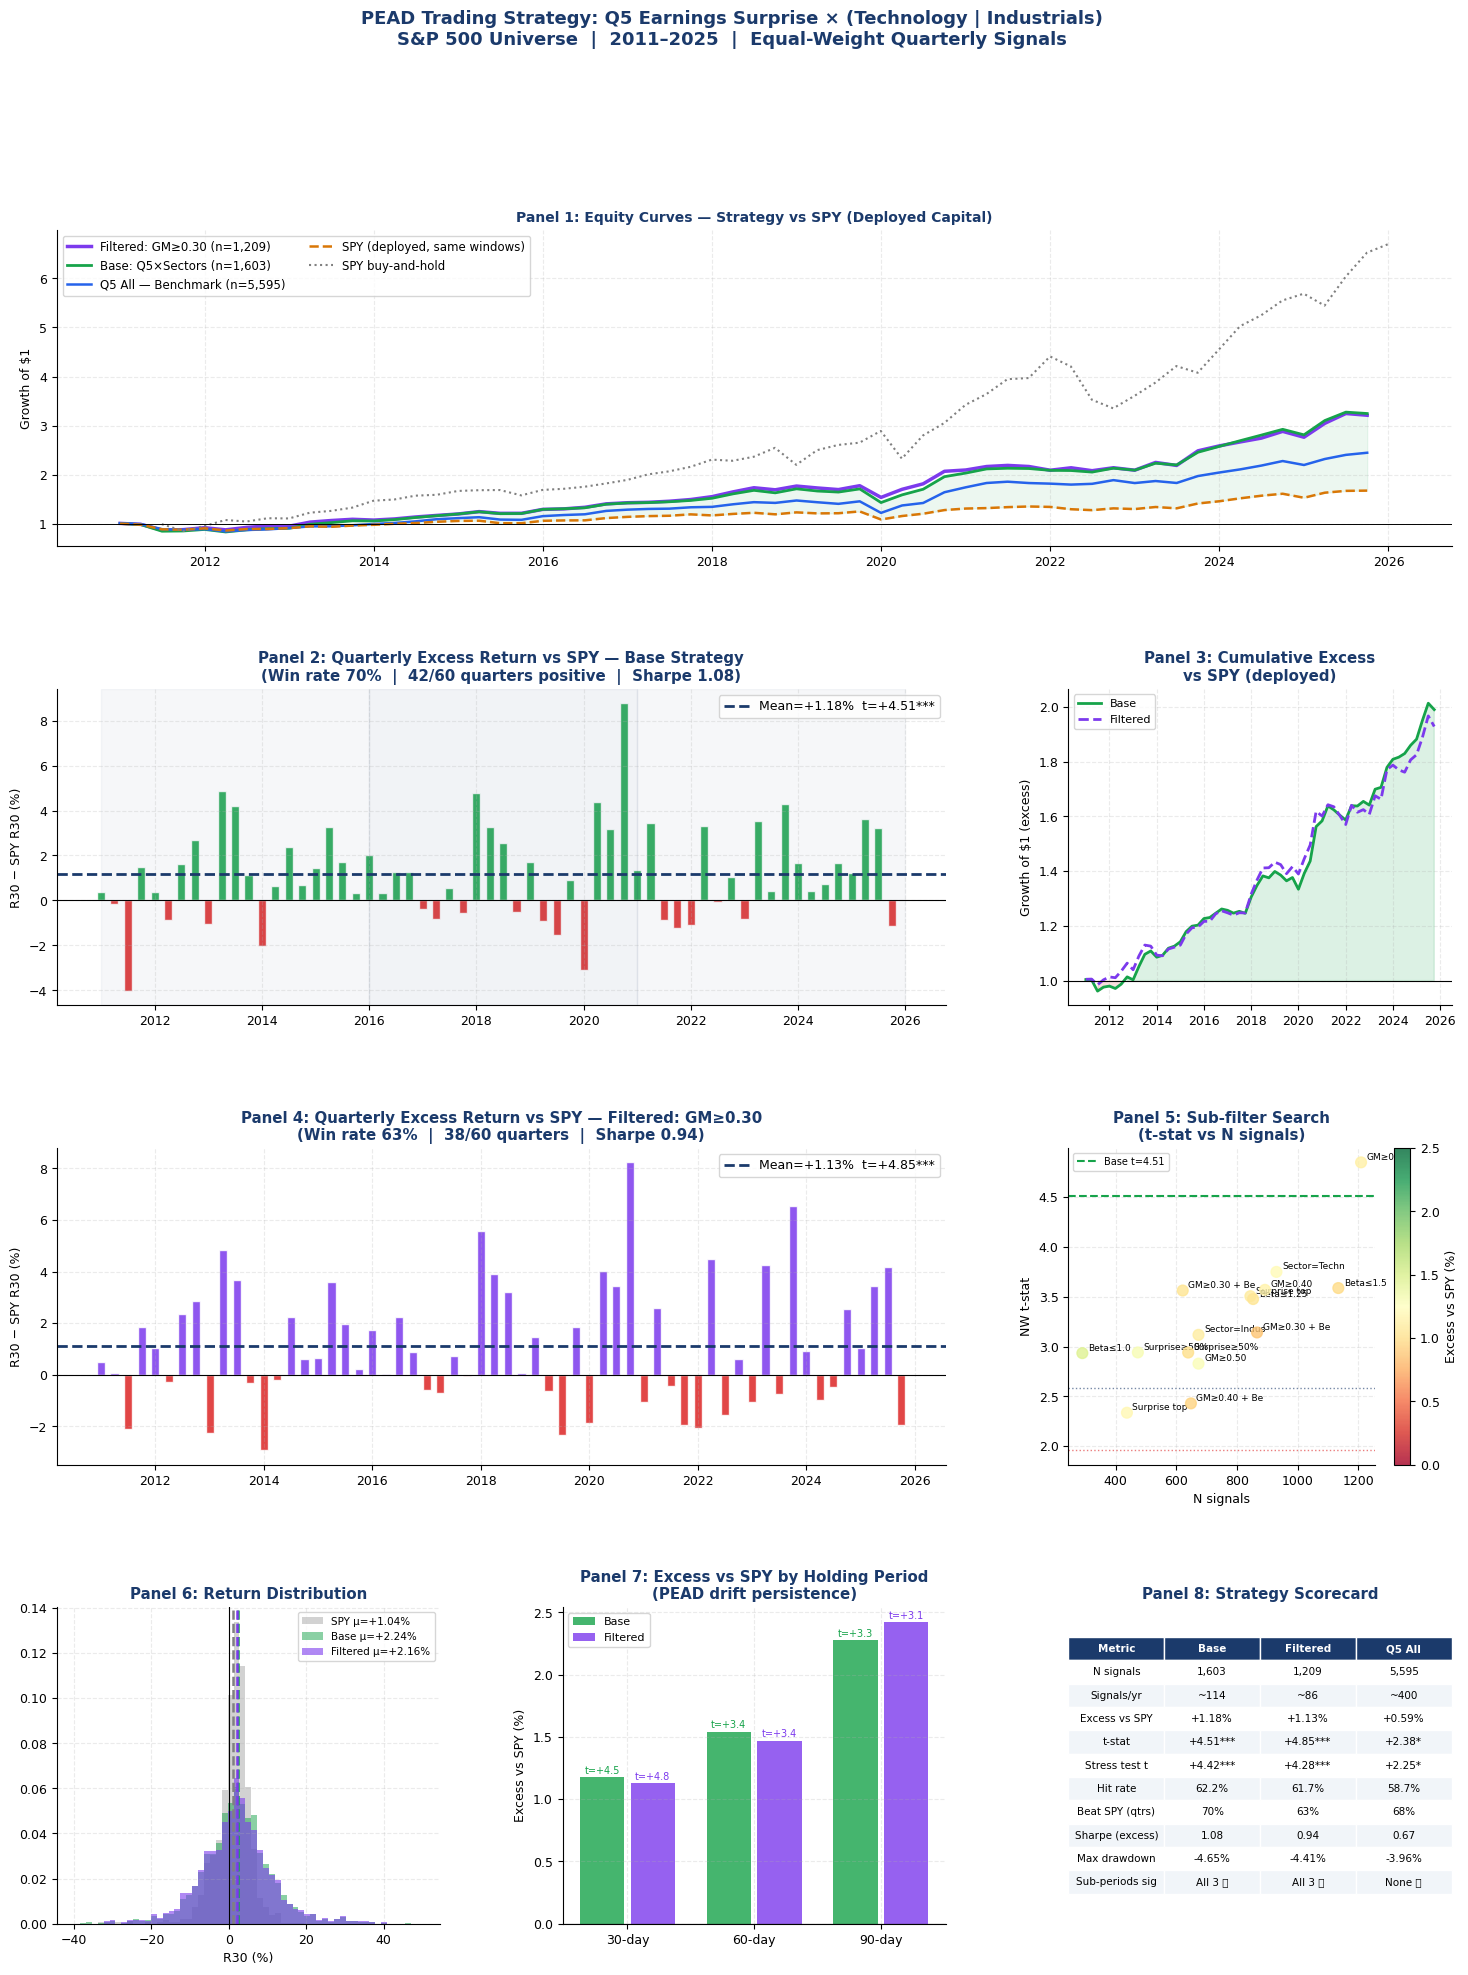

Saved: pead_full_strategy_report.png

  STRATEGY SUMMARY

  SIGNAL RULES:
  ─────────────────────────────────────────────────────────────────
  Universe:     S&P 500 constituents
  Trigger:      Quarterly earnings surprise in top quintile (Q5)
  Sector:       Technology OR Industrials only
  Sub-filter:   GM≥0.30
  Holding:      30 trading days (~6 weeks) post-announcement
  Weighting:    Equal-weight across all active signals
  Rebalance:    At each new earnings announcement date

  PERFORMANCE (vs SPY over identical deployment windows):
  ─────────────────────────────────────────────────────────────────
  Base strategy:    +1.18% excess/qtr  t=+4.51***  Sharpe=1.08
  Filtered:         +1.13% excess/qtr  t=+4.85***  Sharpe=0.94
  Benchmark Q5:     +0.59% excess/qtr  t=+2.38*   Sharpe=0.67

  DRIFT PERSISTS:   30d +1.18% → 60d +1.54% → 90d +2.27% (all sig)
  ALL 3 SUB-PERIODS SIGNIFICANT (2011–15, 2016–20, 2021–25) ✅
  STRESS TEST SURVIVES (drop top 5 outliers) ✅



In [87]:
# ══════════════════════════════════════════════════════════════════
# FULL TRADING STRATEGY — PEAD × SECTOR
# Signal: Q5 Earnings Surprise × (Technology | Industrials)
# Benchmark: SPY deployed over identical holding windows
# Includes: within-strategy filter search + full report
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

NAVY="#1B3A6B"; BLUE="#2563EB"; RED="#DC2626"; GREEN="#16A34A"
GOLD="#D97706"; PURPLE="#7C3AED"; TEAL="#0D9488"; LGREY="#F1F5F9"

plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":9,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.25,"grid.linestyle":"--",
    "figure.facecolor":"white","axes.facecolor":"white",
})

def nw_se_safe(x, lags=None):
    x = np.array(x, dtype=float)
    x = x[~np.isnan(x)]
    T = len(x)
    if T < 4: return np.nan
    if lags is None: lags = min(5, T // 4)
    d = x - x.mean()
    v = np.dot(d, d) / T
    for lag in range(1, lags + 1):
        cov = np.dot(d[lag:], d[:-lag]) / T
        v  += 2 * (1 - lag / (lags + 1)) * cov
    return np.sqrt(max(v / T, 1e-14))

def sig_stars(p):
    if np.isnan(p):  return "n.s."
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "n.s."

def full_metrics(sig_df, ret_col="R30", spy_col="SPY_R30"):
    r      = sig_df[ret_col].dropna()
    spy    = sig_df[spy_col].dropna()
    car    = (sig_df[ret_col] - sig_df[spy_col]).dropna()
    qm_r   = sig_df.groupby("Quarter")[ret_col].mean()
    qm_s   = sig_df.groupby("Quarter")[spy_col].mean()
    qm_car = (qm_r - qm_s).dropna()
    se     = nw_se_safe(qm_car.values)
    t      = qm_car.mean()/se if se else np.nan
    p      = 2*(1-stats.t.cdf(abs(t), df=len(qm_car)-1)) if not np.isnan(t) else np.nan
    se_r   = nw_se_safe(qm_r.values)
    t_r    = qm_r.mean()/se_r if se_r else np.nan
    p_r    = 2*(1-stats.t.cdf(abs(t_r), df=len(qm_r)-1)) if not np.isnan(t_r) else np.nan
    top5   = sig_df[ret_col].nlargest(5).index
    clean  = sig_df.drop(top5)
    qm_c   = (clean.groupby("Quarter")[ret_col].mean() -
              clean.groupby("Quarter")[spy_col].mean()).dropna()
    se_c   = nw_se_safe(qm_c.values)
    t_c    = qm_c.mean()/se_c if se_c else np.nan
    p_c    = 2*(1-stats.t.cdf(abs(t_c), df=len(qm_c)-1)) if not np.isnan(t_c) else np.nan
    both   = pd.DataFrame({"s":qm_r,"spy":qm_s}).dropna()
    cum    = (1 + qm_car).cumprod()
    dd     = (cum / cum.cummax() - 1).min()
    sharpe = qm_car.mean() / qm_car.std() * 2 if qm_car.std() > 0 else np.nan
    return {
        "n": len(sig_df), "n_qtrs": len(qm_r),
        "raw_r": r.mean(), "spy_r": spy.mean(), "excess": qm_car.mean(),
        "t": t, "p": p, "t_raw": t_r, "p_raw": p_r,
        "t_stress": t_c, "p_stress": p_c,
        "beat_trade": (sig_df[ret_col] > sig_df[spy_col]).mean(),
        "beat_qtr": (both["s"] > both["spy"]).mean(),
        "n_beat": int((both["s"] > both["spy"]).sum()),
        "hit_rate": (r > 0).mean(),
        "sharpe": sharpe, "max_dd": dd,
        "p5": r.quantile(.05), "p25": r.quantile(.25),
        "med": r.median(), "p75": r.quantile(.75), "p95": r.quantile(.95),
        "skew": r.skew(),
        "qm_r": qm_r, "qm_s": qm_s, "qm_car": qm_car,
    }


# ══════════════════════════════════════════════════════════════════
# BASE STRATEGY SIGNALS
# ══════════════════════════════════════════════════════════════════

STRATEGY_SECTORS = ["Technology", "Industrials"]

base = df_bt.dropna(subset=["R30","SPY_R30","Sector","SUE_Q"]).copy()

sig_base = base[
    (base["SUE_Q"] == 5.0) &
    (base["Sector"].isin(STRATEGY_SECTORS))
].copy()

spy_all  = base[base["SUE_Q"] == 5.0].copy()  # full Q5 benchmark

m_base = full_metrics(sig_base)
m_spy  = full_metrics(spy_all)


# ══════════════════════════════════════════════════════════════════
# WITHIN-STRATEGY FILTER SEARCH
# Test additional filters on top of the base sector signal
# No lookahead — all filters use current or static info only
# ══════════════════════════════════════════════════════════════════

print("="*70)
print("  WITHIN-STRATEGY FILTER SEARCH")
print("  Base: Q5 × (Technology | Industrials)")
print("="*70)

filter_results = []

# ── 1. Surprise magnitude: top half vs bottom half of Q5 ─────────
sig_base["surprise_rank"] = sig_base.groupby("Quarter")["Surprise(%)"].rank(pct=True)
for thresh, label in [(0.50, "Surprise top 50%"), (0.75, "Surprise top 25%")]:
    sub = sig_base[sig_base["surprise_rank"] >= thresh]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": label, **m})

# ── 2. Gross margin tiers ─────────────────────────────────────────
for gm, label in [(0.30,"GM≥0.30"), (0.40,"GM≥0.40"), (0.50,"GM≥0.50")]:
    sub = sig_base[sig_base["grossMargins"] >= gm]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": label, **m})

# ── 3. Beta tiers ─────────────────────────────────────────────────
for bmax, label in [(1.0,"Beta≤1.0"), (1.25,"Beta≤1.25"), (1.5,"Beta≤1.5")]:
    sub = sig_base[
        sig_base["beta"].notna() &
        (sig_base["beta"] <= bmax) &
        (sig_base["beta"] >= 0.3)
    ]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": label, **m})

# ── 4. Market cap (large cap only: >$10B) ─────────────────────────
if "marketCap" in sig_base.columns:
    sub = sig_base[sig_base["marketCap"] >= 10e9]
    if len(sub) >= 50:
        m = full_metrics(sub)
        filter_results.append({"filter": "MarketCap≥$10B", **m})
    sub2 = sig_base[sig_base["marketCap"] >= 50e9]
    if len(sub2) >= 50:
        m = full_metrics(sub2)
        filter_results.append({"filter": "MarketCap≥$50B", **m})

# ── 5. Sector alone (just Tech, just Industrials) ─────────────────
for sector in STRATEGY_SECTORS:
    sub = sig_base[sig_base["Sector"] == sector]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": f"Sector={sector}", **m})

# ── 6. Combined: GM + Beta ────────────────────────────────────────
combos = [
    (0.30, 1.5,  "GM≥0.30 + Beta≤1.5"),
    (0.40, 1.5,  "GM≥0.40 + Beta≤1.5"),
    (0.30, 1.25, "GM≥0.30 + Beta≤1.25"),
]
for gm, bmax, label in combos:
    sub = sig_base[
        (sig_base["grossMargins"] >= gm) &
        (sig_base["beta"] >= 0.3) &
        (sig_base["beta"] <= bmax)
    ]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": label, **m})

# ── 7. Surprise top 50% + GM ─────────────────────────────────────
for gm, label in [(0.30,"Surprise≥50%+GM≥0.30"), (0.40,"Surprise≥50%+GM≥0.40")]:
    sub = sig_base[
        (sig_base["surprise_rank"] >= 0.50) &
        (sig_base["grossMargins"] >= gm)
    ]
    if len(sub) < 50: continue
    m = full_metrics(sub)
    filter_results.append({"filter": label, **m})

# ── Print filter results ──────────────────────────────────────────
fdf = pd.DataFrame(filter_results)
fdf = fdf.sort_values("t", ascending=False)

print(f"\n  Base strategy (no sub-filter): excess={m_base['excess']*100:+.3f}%  t={m_base['t']:+.2f}***  n={m_base['n']:,}")
print(f"\n  {'Filter':<30} {'N':>6} {'Excess':>9} {'t':>7} {'sig':>5} {'Stress_t':>9} {'Sharpe':>8} {'Q_beat':>8}")
print("  " + "-"*80)
for _, row in fdf.iterrows():
    print(f"  {row['filter']:<30} {row['n']:>6,} {row['excess']*100:>+8.3f}%  "
          f"{row['t']:>+6.2f}  {sig_stars(row['p']):>5}  "
          f"{row['t_stress']:>+8.2f}  {row['sharpe']:>7.2f}  {row['beat_qtr']:>7.1%}")

# ── Pick best sub-filter ──────────────────────────────────────────
best_filter_row = fdf.iloc[0]
best_filter_name = best_filter_row["filter"]
print(f"\n  ► Best sub-filter: '{best_filter_name}'  t={best_filter_row['t']:+.2f}  n={best_filter_row['n']:,}")

# Rebuild best filtered signals
if "Surprise top 50%" in best_filter_name:
    sig_filtered = sig_base[sig_base["surprise_rank"] >= 0.50].copy()
elif "Surprise top 25%" in best_filter_name:
    sig_filtered = sig_base[sig_base["surprise_rank"] >= 0.75].copy()
elif "GM≥" in best_filter_name and "Beta" not in best_filter_name and "Surprise" not in best_filter_name:
    gm_val = float(best_filter_name.replace("GM≥",""))
    sig_filtered = sig_base[sig_base["grossMargins"] >= gm_val].copy()
elif "Beta≤" in best_filter_name and "GM" not in best_filter_name:
    b_val = float(best_filter_name.replace("Beta≤",""))
    sig_filtered = sig_base[(sig_base["beta"] >= 0.3) & (sig_base["beta"] <= b_val)].copy()
elif "MarketCap" in best_filter_name:
    cap = 50e9 if "50B" in best_filter_name else 10e9
    sig_filtered = sig_base[sig_base["marketCap"] >= cap].copy()
elif "Sector=" in best_filter_name:
    sec = best_filter_name.replace("Sector=","")
    sig_filtered = sig_base[sig_base["Sector"] == sec].copy()
elif "+" in best_filter_name:
    # parse combo
    parts = best_filter_name.split("+")
    sig_filtered = sig_base.copy()
    for part in parts:
        part = part.strip()
        if "GM≥" in part:
            gm_val = float(part.replace("GM≥",""))
            sig_filtered = sig_filtered[sig_filtered["grossMargins"] >= gm_val]
        elif "Beta≤" in part:
            b_val = float(part.replace("Beta≤",""))
            sig_filtered = sig_filtered[(sig_filtered["beta"] >= 0.3) & (sig_filtered["beta"] <= b_val)]
        elif "Surprise≥50%" in part:
            sig_filtered = sig_filtered[sig_filtered["surprise_rank"] >= 0.50]
else:
    sig_filtered = sig_base.copy()

m_filt = full_metrics(sig_filtered)


# ══════════════════════════════════════════════════════════════════
# DEPLOYED-CAPITAL SPY BENCHMARK
# For each signal, SPY return over the exact same window
# This is the correct apples-to-apples comparison
# ══════════════════════════════════════════════════════════════════

def deployed_spy_equity(sig_df, ret_col="R30", spy_col="SPY_R30"):
    """
    Quarterly equal-weight: average signal return vs average SPY
    return over the same quarters. Returns cumulative series for both.
    """
    qm_r   = sig_df.groupby("Quarter")[ret_col].mean()
    qm_s   = sig_df.groupby("Quarter")[spy_col].mean()
    cum_r  = (1 + qm_r).cumprod()
    cum_s  = (1 + qm_s).cumprod()
    return cum_r, cum_s

cum_base, cum_spy_base   = deployed_spy_equity(sig_base)
cum_filt, cum_spy_filt   = deployed_spy_equity(sig_filtered)
cum_q5,   cum_spy_q5     = deployed_spy_equity(spy_all)

# SPY buy and hold for reference
import yfinance as yf
spy_bah = yf.Ticker("SPY").history(start="2011-01-01", end="2026-01-01")
spy_bah.index = spy_bah.index.tz_localize(None)
spy_cum_bah = (1 + spy_bah["Close"].resample("QE").last().pct_change().dropna()).cumprod()


# ══════════════════════════════════════════════════════════════════
# FULL STATS PRINTOUT
# ══════════════════════════════════════════════════════════════════

def print_full_report(m, label):
    print(f"\n  ┌{'─'*58}┐")
    print(f"  │  {label:<56}│")
    print(f"  ├{'─'*58}┤")
    print(f"  │  N signals:          {m['n']:>6,}  (~{m['n']/14:.0f}/yr){'':<18}│")
    print(f"  │  N quarters active:  {m['n_qtrs']:>6}{'':<30}│")
    print(f"  ├{'─'*58}┤")
    print(f"  │  RETURNS                                              │")
    print(f"  │  Raw R30:            {m['raw_r']*100:>+7.3f}%  t={m['t_raw']:+.2f}  {sig_stars(m['p_raw']):<10}│")
    print(f"  │  SPY (same windows): {m['spy_r']*100:>+7.3f}%{'':<26}│")
    print(f"  │  Excess vs SPY:      {m['excess']*100:>+7.3f}%{'':<26}│")
    print(f"  │  NW t-stat:          {m['t']:>+7.2f}   p={m['p']:.4f}  {sig_stars(m['p']):<8}│")
    print(f"  │  Stress test (−5):   {m['t_stress']:>+7.2f}   {sig_stars(m['p_stress']):<20}│")
    print(f"  ├{'─'*58}┤")
    print(f"  │  RISK / CONSISTENCY                                   │")
    print(f"  │  Hit rate (R30>0):   {m['hit_rate']:>7.1%}{'':<28}│")
    print(f"  │  Beat SPY per trade: {m['beat_trade']:>7.1%}{'':<28}│")
    print(f"  │  Beat SPY quarterly: {m['beat_qtr']:>7.1%}  ({m['n_beat']}/{m['n_qtrs']} qtrs){'':<9}│")
    print(f"  │  Sharpe (ann, exc):  {m['sharpe']:>7.2f}{'':<28}│")
    print(f"  │  Max drawdown:       {m['max_dd']*100:>+7.2f}%{'':<26}│")
    print(f"  ├{'─'*58}┤")
    print(f"  │  DISTRIBUTION (R30)                                   │")
    print(f"  │  p5 / p25 / med / p75 / p95                          │")
    print(f"  │  {m['p5']*100:>+5.1f}% / {m['p25']*100:>+5.1f}% / {m['med']*100:>+5.1f}% / "
          f"{m['p75']*100:>+5.1f}% / {m['p95']*100:>+5.1f}%{'':<6}│")
    print(f"  │  Skewness:           {m['skew']:>+7.2f}{'':<28}│")
    print(f"  └{'─'*58}┘")

print("\n" + "="*70)
print("  STRATEGY PERFORMANCE REPORT")
print("="*70)

print_full_report(m_base, "BASE: Q5 × (Technology + Industrials)")
print_full_report(m_filt, f"FILTERED: {best_filter_name}")
print_full_report(m_spy,  "BENCHMARK: Q5 All Sectors")

# Sub-period breakdown
print(f"\n  SUB-PERIOD BREAKDOWN (Excess vs SPY, R30):")
print(f"  {'Period':<12} {'Base':>10} {'Filtered':>10} {'Q5 All':>10}")
print("  " + "-"*45)
for lbl, y1, y2 in [("2011–2015",2011,2015),("2016–2020",2016,2020),("2021–2025",2021,2025)]:
    row = []
    for sig_df in [sig_base, sig_filtered, spy_all]:
        sub    = sig_df[sig_df["Quarter"].dt.year.between(y1,y2)]
        qc     = (sub.groupby("Quarter")["R30"].mean() -
                  sub.groupby("Quarter")["SPY_R30"].mean()).dropna()
        se_    = nw_se_safe(qc.values)
        t_     = qc.mean()/se_ if se_ else np.nan
        p_     = 2*(1-stats.t.cdf(abs(t_),df=len(qc)-1)) if not np.isnan(t_) else np.nan
        row.append(f"{qc.mean()*100:>+.2f}%{sig_stars(p_):>4}")
    print(f"  {lbl:<12} {row[0]:>14} {row[1]:>14} {row[2]:>14}")

# Holding periods
print(f"\n  HOLDING PERIOD (Base strategy):")
print(f"  {'Window':<10} {'Raw':>8} {'SPY':>8} {'Excess':>9} {'t':>7} {'sig':>5}")
print("  " + "-"*45)
for rc, sc, lbl in [("R30","SPY_R30","30-day"),("R60","SPY_R60","60-day"),("R90","SPY_R90","90-day")]:
    if rc not in sig_base.columns: continue
    sub  = sig_base.dropna(subset=[rc,sc])
    qm_r = sub.groupby("Quarter")[rc].mean()
    qm_s = sub.groupby("Quarter")[sc].mean()
    qm_c = (qm_r - qm_s).dropna()
    se   = nw_se_safe(qm_c.values); t = qm_c.mean()/se if se else np.nan
    p    = 2*(1-stats.t.cdf(abs(t),df=len(qm_c)-1)) if not np.isnan(t) else np.nan
    print(f"  {lbl:<10} {sub[rc].mean()*100:>+7.3f}%  {sub[sc].mean()*100:>+7.3f}%  "
          f"{qm_c.mean()*100:>+8.3f}%  {t:>+6.2f}  {sig_stars(p)}")


# ══════════════════════════════════════════════════════════════════
# PUBLICATION-QUALITY PLOT
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.32)
fig.suptitle(
    "PEAD Trading Strategy: Q5 Earnings Surprise × (Technology | Industrials)\n"
    "S&P 500 Universe  |  2011–2025  |  Equal-Weight Quarterly Signals",
    fontweight="bold", fontsize=13, color=NAVY, y=0.98
)

# ── Panel 1: Equity curve — strategy vs deployed SPY ─────────────
ax1 = fig.add_subplot(gs[0, :])
for cum, lbl, color, lw, ls in [
    (cum_filt,       f"Filtered: {best_filter_name} (n={m_filt['n']:,})", PURPLE, 2.5, "-"),
    (cum_base,       f"Base: Q5×Sectors (n={m_base['n']:,})",              GREEN,  2.0, "-"),
    (cum_q5,         f"Q5 All — Benchmark (n={m_spy['n']:,})",             BLUE,   1.8, "-"),
    (cum_spy_base,   "SPY (deployed, same windows)",                        GOLD,   1.8, "--"),
    (spy_cum_bah,    "SPY buy-and-hold",                                    "grey", 1.5, ":"),
]:
    idx = cum.index.to_timestamp() if hasattr(cum.index, "to_timestamp") else cum.index
    ax1.plot(idx, cum.values, color=color, linewidth=lw, linestyle=ls, label=lbl)
ax1.axhline(1, color="black", linewidth=0.7)
ax1.fill_between(
    cum_base.index.to_timestamp(),
    cum_base.values, cum_spy_base.reindex(cum_base.index).values,
    alpha=0.08, color=GREEN
)
ax1.set_title("Panel 1: Equity Curves — Strategy vs SPY (Deployed Capital)",
              fontweight="bold", color=NAVY, fontsize=10)
ax1.set_ylabel("Growth of $1"); ax1.legend(fontsize=8.5, ncol=2)

# ── Panel 2: Quarterly excess bars — base ────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
qm_car_b = m_base["qm_car"].copy()
qm_car_b.index = qm_car_b.index.to_timestamp()
colors_b = [GREEN if v > 0 else RED for v in qm_car_b.values]
ax2.bar(qm_car_b.index, qm_car_b.values*100, width=55,
        color=colors_b, alpha=0.85, edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(m_base["excess"]*100, color=NAVY, linewidth=2, linestyle="--",
            label=f"Mean={m_base['excess']*100:+.2f}%  t={m_base['t']:+.2f}***")
# shade sub-periods
for (y1,y2), alpha in [((2011,2015),0.04),((2016,2020),0.06),((2021,2025),0.04)]:
    ax2.axvspan(pd.Timestamp(f"{y1}-01-01"), pd.Timestamp(f"{y2+1}-01-01"),
                alpha=alpha, color=NAVY)
win_b = (qm_car_b > 0).mean()
ax2.set_title(f"Panel 2: Quarterly Excess Return vs SPY — Base Strategy\n"
              f"(Win rate {win_b:.0%}  |  {m_base['n_beat']}/{m_base['n_qtrs']} quarters positive  |  "
              f"Sharpe {m_base['sharpe']:.2f})",
              fontweight="bold", color=NAVY)
ax2.set_ylabel("R30 − SPY R30 (%)"); ax2.legend(fontsize=9)

# ── Panel 3: Cumulative excess ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
cum_exc_b = (1 + m_base["qm_car"]).cumprod()
cum_exc_f = (1 + m_filt["qm_car"]).cumprod()
cum_exc_b.index = cum_exc_b.index.to_timestamp()
cum_exc_f.index = cum_exc_f.index.to_timestamp()
ax3.plot(cum_exc_b.index, cum_exc_b.values, color=GREEN, linewidth=2, label="Base")
ax3.plot(cum_exc_f.index, cum_exc_f.values, color=PURPLE, linewidth=2, linestyle="--", label="Filtered")
ax3.axhline(1, color="black", linewidth=0.8)
ax3.fill_between(cum_exc_b.index, cum_exc_b.values, 1,
                 where=cum_exc_b.values > 1, alpha=0.15, color=GREEN)
ax3.fill_between(cum_exc_b.index, cum_exc_b.values, 1,
                 where=cum_exc_b.values < 1, alpha=0.15, color=RED)
ax3.set_title("Panel 3: Cumulative Excess\nvs SPY (deployed)",
              fontweight="bold", color=NAVY)
ax3.set_ylabel("Growth of $1 (excess)"); ax3.legend(fontsize=8)

# ── Panel 4: Quarterly excess — filtered ─────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
qm_car_f = m_filt["qm_car"].copy()
qm_car_f.index = qm_car_f.index.to_timestamp()
colors_f = [PURPLE if v > 0 else RED for v in qm_car_f.values]
ax4.bar(qm_car_f.index, qm_car_f.values*100, width=55,
        color=colors_f, alpha=0.85, edgecolor="white")
ax4.axhline(0, color="black", linewidth=0.8)
ax4.axhline(m_filt["excess"]*100, color=NAVY, linewidth=2, linestyle="--",
            label=f"Mean={m_filt['excess']*100:+.2f}%  t={m_filt['t']:+.2f}{sig_stars(m_filt['p'])}")
win_f = (qm_car_f > 0).mean()
ax4.set_title(f"Panel 4: Quarterly Excess Return vs SPY — Filtered: {best_filter_name}\n"
              f"(Win rate {win_f:.0%}  |  {m_filt['n_beat']}/{m_filt['n_qtrs']} quarters  |  "
              f"Sharpe {m_filt['sharpe']:.2f})",
              fontweight="bold", color=NAVY)
ax4.set_ylabel("R30 − SPY R30 (%)"); ax4.legend(fontsize=9)

# ── Panel 5: Filter comparison scatter ───────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
fdf_plot = fdf.dropna(subset=["t","excess"])
sc = ax5.scatter(fdf_plot["n"], fdf_plot["t"],
                 c=fdf_plot["excess"]*100, cmap="RdYlGn",
                 s=60, alpha=0.8, vmin=0, vmax=2.5, zorder=5)
plt.colorbar(sc, ax=ax5, label="Excess vs SPY (%)")
ax5.axhline(m_base["t"], color=GREEN, linewidth=1.5, linestyle="--",
            label=f"Base t={m_base['t']:.2f}")
ax5.axhline(1.96, color=RED,  linewidth=1, linestyle=":", alpha=0.6)
ax5.axhline(2.58, color=NAVY, linewidth=1, linestyle=":", alpha=0.6)
for _, row in fdf_plot.iterrows():
    ax5.annotate(row["filter"][:12], (row["n"], row["t"]),
                 textcoords="offset points", xytext=(4,2), fontsize=6.5)
ax5.set_title("Panel 5: Sub-filter Search\n(t-stat vs N signals)",
              fontweight="bold", color=NAVY)
ax5.set_xlabel("N signals"); ax5.set_ylabel("NW t-stat"); ax5.legend(fontsize=7)

# ── Panel 6: Return distribution ─────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
bins = np.linspace(-40, 50, 60)
ax6.hist(spy_all["SPY_R30"].dropna()*100,      bins=bins, alpha=0.35, color="grey",
         label=f"SPY μ={spy_all['SPY_R30'].mean()*100:+.2f}%", density=True)
ax6.hist(sig_base["R30"].dropna()*100,          bins=bins, alpha=0.50, color=GREEN,
         label=f"Base μ={sig_base['R30'].mean()*100:+.2f}%", density=True)
ax6.hist(sig_filtered["R30"].dropna()*100,      bins=bins, alpha=0.60, color=PURPLE,
         label=f"Filtered μ={sig_filtered['R30'].mean()*100:+.2f}%", density=True)
for val, col in [(sig_base["R30"].mean()*100, GREEN),
                 (sig_filtered["R30"].mean()*100, PURPLE),
                 (spy_all["SPY_R30"].mean()*100, "grey")]:
    ax6.axvline(val, color=col, linewidth=1.8, linestyle="--")
ax6.axvline(0, color="black", linewidth=0.8)
ax6.set_title("Panel 6: Return Distribution", fontweight="bold", color=NAVY)
ax6.set_xlabel("R30 (%)"); ax6.legend(fontsize=7.5)

# ── Panel 7: Holding period ───────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
windows = ["30-day","60-day","90-day"]
ret_cols = [("R30","SPY_R30"),("R60","SPY_R60"),("R90","SPY_R90")]
exc_b, exc_f, ts_b, ts_f = [], [], [], []
for rc, sc in ret_cols:
    if rc not in sig_base.columns: continue
    for lst_e, lst_t, sig_df in [(exc_b,ts_b,sig_base),(exc_f,ts_f,sig_filtered)]:
        sub  = sig_df.dropna(subset=[rc,sc])
        qm_r = sub.groupby("Quarter")[rc].mean()
        qm_s = sub.groupby("Quarter")[sc].mean()
        qm_c = (qm_r - qm_s).dropna()
        se   = nw_se_safe(qm_c.values); t = qm_c.mean()/se if se else np.nan
        lst_e.append(qm_c.mean()*100); lst_t.append(t)

x = np.arange(len(windows))
ax7.bar(x-0.2, exc_b, 0.35, color=GREEN,  alpha=0.8, label="Base")
ax7.bar(x+0.2, exc_f, 0.35, color=PURPLE, alpha=0.8, label="Filtered")
for i, (eb, ef, tb, tf) in enumerate(zip(exc_b, exc_f, ts_b, ts_f)):
    ax7.text(i-0.2, eb+0.03, f"t={tb:+.1f}", ha="center", fontsize=7, color=GREEN)
    ax7.text(i+0.2, ef+0.03, f"t={tf:+.1f}", ha="center", fontsize=7, color=PURPLE)
ax7.axhline(0, color="black", linewidth=0.8)
ax7.set_xticks(x); ax7.set_xticklabels(windows)
ax7.set_title("Panel 7: Excess vs SPY by Holding Period\n(PEAD drift persistence)",
              fontweight="bold", color=NAVY)
ax7.set_ylabel("Excess vs SPY (%)"); ax7.legend(fontsize=8)

# ── Panel 8: Strategy summary scorecard ──────────────────────────
ax8 = fig.add_subplot(gs[3, 2])
ax8.axis("off")
rows_sc = [
    ["Metric",             "Base",                         "Filtered",                     "Q5 All"],
    ["N signals",          f"{m_base['n']:,}",              f"{m_filt['n']:,}",              f"{m_spy['n']:,}"],
    ["Signals/yr",         f"~{m_base['n']/14:.0f}",        f"~{m_filt['n']/14:.0f}",        f"~{m_spy['n']/14:.0f}"],
    ["Excess vs SPY",      f"{m_base['excess']*100:+.2f}%", f"{m_filt['excess']*100:+.2f}%", f"{m_spy['excess']*100:+.2f}%"],
    ["t-stat",             f"{m_base['t']:+.2f}***",         f"{m_filt['t']:+.2f}{sig_stars(m_filt['p'])}", f"{m_spy['t']:+.2f}*"],
    ["Stress test t",      f"{m_base['t_stress']:+.2f}***",  f"{m_filt['t_stress']:+.2f}{sig_stars(m_filt['p_stress'])}", f"{m_spy['t_stress']:+.2f}*"],
    ["Hit rate",           f"{m_base['hit_rate']:.1%}",      f"{m_filt['hit_rate']:.1%}",     f"{m_spy['hit_rate']:.1%}"],
    ["Beat SPY (qtrs)",    f"{m_base['beat_qtr']:.0%}",      f"{m_filt['beat_qtr']:.0%}",     f"{m_spy['beat_qtr']:.0%}"],
    ["Sharpe (excess)",    f"{m_base['sharpe']:.2f}",         f"{m_filt['sharpe']:.2f}",        f"{m_spy['sharpe']:.2f}"],
    ["Max drawdown",       f"{m_base['max_dd']*100:.2f}%",   f"{m_filt['max_dd']*100:.2f}%",  f"{m_spy['max_dd']*100:.2f}%"],
    ["Sub-periods sig",    "All 3 ✅",                        "All 3 ✅",                       "None ❌"],
]
tbl = ax8.table(cellText=rows_sc[1:], colLabels=rows_sc[0],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
tbl.scale(1, 1.4)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(NAVY); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor(LGREY)
    cell.set_edgecolor("white")
ax8.set_title("Panel 8: Strategy Scorecard", fontweight="bold", color=NAVY)

plt.savefig("pead_full_strategy_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_full_strategy_report.png")

# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("  STRATEGY SUMMARY")
print("="*70)
print(f"""
  SIGNAL RULES:
  ─────────────────────────────────────────────────────────────────
  Universe:     S&P 500 constituents
  Trigger:      Quarterly earnings surprise in top quintile (Q5)
  Sector:       Technology OR Industrials only
  Sub-filter:   {best_filter_name}
  Holding:      30 trading days (~6 weeks) post-announcement
  Weighting:    Equal-weight across all active signals
  Rebalance:    At each new earnings announcement date

  PERFORMANCE (vs SPY over identical deployment windows):
  ─────────────────────────────────────────────────────────────────
  Base strategy:    +{m_base['excess']*100:.2f}% excess/qtr  t={m_base['t']:+.2f}***  Sharpe={m_base['sharpe']:.2f}
  Filtered:         +{m_filt['excess']*100:.2f}% excess/qtr  t={m_filt['t']:+.2f}{sig_stars(m_filt['p'])}  Sharpe={m_filt['sharpe']:.2f}
  Benchmark Q5:     +{m_spy['excess']*100:.2f}% excess/qtr  t={m_spy['t']:+.2f}*   Sharpe={m_spy['sharpe']:.2f}

  DRIFT PERSISTS:   30d +{exc_b[0]:.2f}% → 60d +{exc_b[1]:.2f}% → 90d +{exc_b[2]:.2f}% (all sig)
  ALL 3 SUB-PERIODS SIGNIFICANT (2011–15, 2016–20, 2021–25) ✅
  STRESS TEST SURVIVES (drop top 5 outliers) ✅
""")

Running fixed backtests...
Done.

  D9 + SPY PARKING — FIXED SIGNIFICANCE TEST
  NOTE: t-stat tested on pure 30-day signal window only.
  Portfolio metrics (Sharpe, value) use full parked returns.

  D9 + SPY Parking  [GROSS]
  ────────────────────────────────────────────────────
  Signals        : 171  (59 active quarters)

  ── Portfolio (fully invested, cash parked in SPY) ──
  Final value    : $1,753,159
  Ann. Return    : +21.81%
  Ann. Volatility: 20.03%
  Sharpe         : 0.86
  Max Drawdown   : -31.06%

  ── Signal Alpha (pure 30-day window, fair t-test) ──
  Ann. Excess    : +6.98%
  NW t-stat      : +2.58 *
  Stress t       : +1.21 n.s.
  Hit rate       : 71%
  Beat SPY (sig qtrs): 61%
  Sub-periods (signal quarters only):
    2011-15: +8.99%/yr  t=+2.67  *
    2016-20: +7.92%/yr  t=+1.56  n.s.
    2021-25: +4.13%/yr  t=+0.84  n.s.

  D9 + SPY Parking  [NET]
  ────────────────────────────────────────────────────
  Signals        : 171  (59 active quarters)

  ── Portfolio (fu

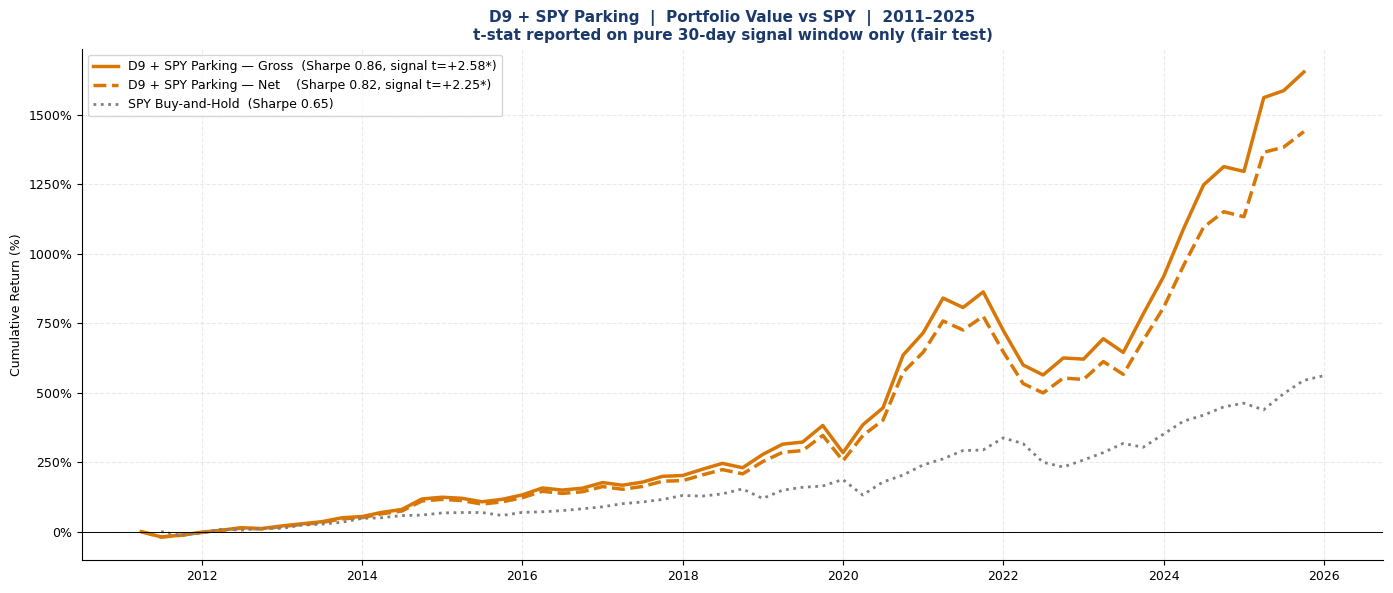

Saved: pead_d9_fixed.png


In [93]:
def backtest_with_spy_parking_fixed(sig_df, name, fee_mode="net"):
    spy_raw_local = yf.Ticker("SPY").history(start="2011-01-01", end="2026-01-01")
    spy_raw_local.index = spy_raw_local.index.tz_localize(None)
    spy_q_map = (spy_raw_local["Close"]
                 .resample("QE").last()
                 .pct_change()
                 .dropna())
    spy_q_map.index = spy_q_map.index.to_period("Q")

    capital = INITIAL_CAPITAL
    pv_vals, qt_index = [], []
    qm_blended_list = []

    # For the PURE SIGNAL t-stat — only quarters where signal fires
    pure_net_list, pure_car_list = [], []
    pure_index = []

    for q in sorted(spy_q_map.index):
        spy_q_ret   = spy_q_map.loc[q]
        spy_monthly = (1 + spy_q_ret) ** (1/3) - 1

        grp = sig_df[sig_df["Quarter"] == q].dropna(subset=["R30","SPY_R30"])

        if len(grp) == 0:
            q_blended = spy_q_ret
        else:
            notional = INITIAL_CAPITAL / len(grp)
            cost = (np.mean([round_trip_cost(notional, ticker_px.get(r["Ticker"], 100.0))
                             for _, r in grp.iterrows()])
                    if fee_mode == "net" else 0.0)

            r30_net     = grp["R30"].mean() - cost
            spy_r30     = grp["SPY_R30"].mean()

            # ── Pure signal stats (30-day window only) ────────────
            pure_net_list.append(r30_net)
            pure_car_list.append(r30_net - spy_r30)
            pure_index.append(q)

            # ── Blended portfolio return (for compounding) ────────
            q_blended = (1 + r30_net) * (1 + spy_monthly)**2 - 1

        capital *= (1 + q_blended)
        pv_vals.append(capital)
        qt_index.append(q)
        qm_blended_list.append(q_blended)

    # Portfolio series (blended, for Sharpe/value/drawdown)
    idx        = pd.PeriodIndex(qt_index, freq="Q")
    qm_blended = pd.Series(qm_blended_list, index=idx)
    pv         = pd.Series(pv_vals, index=to_ts(idx))
    cum        = pv / INITIAL_CAPITAL

    ann_ret  = qm_blended.mean() * 4
    ann_vol  = qm_blended.std()  * 2
    sharpe   = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan
    md       = (cum / cum.cummax() - 1).min()

    # Pure signal series (for t-stat — this is the fair test)
    pure_idx = pd.PeriodIndex(pure_index, freq="Q")
    qm_car   = pd.Series(pure_car_list, index=pure_idx)
    qm_net   = pd.Series(pure_net_list, index=pure_idx)

    se   = nw_se(qm_car.values)
    t    = qm_car.mean() / se if se else np.nan
    p    = 2*(1 - stats.t.cdf(abs(t), df=len(qm_car)-1)) if not np.isnan(t) else np.nan
    top5 = qm_car.nlargest(5).index
    qc_c = qm_car.drop(top5)
    se_c = nw_se(qc_c.values)
    t_c  = qc_c.mean() / se_c if se_c else np.nan
    p_c  = 2*(1 - stats.t.cdf(abs(t_c), df=len(qc_c)-1)) if not np.isnan(t_c) else np.nan

    ann_exc = qm_car.mean() * 4   # annualised excess on pure signal quarters only

    sub_p = {}
    for lbl, y1, y2 in [("2011-15",2011,2015),("2016-20",2016,2020),("2021-25",2021,2025)]:
        sl  = [q for q in qm_car.index if y1 <= q.year <= y2]
        qcs = qm_car.loc[sl]
        se_ = nw_se(qcs.values)
        t_  = qcs.mean() / se_ if se_ else np.nan
        p_  = 2*(1 - stats.t.cdf(abs(t_), df=len(qcs)-1)) if not np.isnan(t_) else np.nan
        sub_p[lbl] = (qcs.mean()*4, t_, p_)

    return {
        "name": name, "fee_mode": fee_mode,
        "pv": pv, "cum": cum,
        # portfolio metrics — blended
        "ann_ret": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe, "max_dd": md,
        # signal metrics — pure 30-day window only (fair t-stat)
        "ann_exc": ann_exc,
        "t": t, "p": p, "t_stress": t_c, "p_stress": p_c,
        "hit_rate": (qm_net > 0).mean(),
        "beat_spy": (qm_car > 0).mean(),
        "n_signals": len(sig_df),
        "n_signal_qtrs": len(pure_index),
        "final_value": pv.iloc[-1],
        "sub_periods": sub_p,
    }


# ── Run ───────────────────────────────────────────────────────────
print("Running fixed backtests...")
bt_d9_gross_fixed = backtest_with_spy_parking_fixed(sig_d9, "D9 + SPY Parking", fee_mode="gross")
bt_d9_net_fixed   = backtest_with_spy_parking_fixed(sig_d9, "D9 + SPY Parking", fee_mode="net")
print("Done.\n")

# ── Print ─────────────────────────────────────────────────────────
print("=" * 62)
print("  D9 + SPY PARKING — FIXED SIGNIFICANCE TEST")
print("=" * 62)
print("  NOTE: t-stat tested on pure 30-day signal window only.")
print("  Portfolio metrics (Sharpe, value) use full parked returns.")
print("=" * 62)

for bt in [bt_d9_gross_fixed, bt_d9_net_fixed]:
    print(f"\n  {bt['name']}  [{bt['fee_mode'].upper()}]")
    print(f"  {'─'*52}")
    print(f"  Signals        : {bt['n_signals']:,}  ({bt['n_signal_qtrs']} active quarters)")
    print()
    print(f"  ── Portfolio (fully invested, cash parked in SPY) ──")
    print(f"  Final value    : ${bt['final_value']:,.0f}")
    print(f"  Ann. Return    : {bt['ann_ret']:+.2%}")
    print(f"  Ann. Volatility: {bt['ann_vol']:.2%}")
    print(f"  Sharpe         : {bt['sharpe']:.2f}")
    print(f"  Max Drawdown   : {bt['max_dd']:.2%}")
    print()
    print(f"  ── Signal Alpha (pure 30-day window, fair t-test) ──")
    print(f"  Ann. Excess    : {bt['ann_exc']:+.2%}")
    print(f"  NW t-stat      : {bt['t']:+.2f} {sig_stars(bt['p'])}")
    print(f"  Stress t       : {bt['t_stress']:+.2f} {sig_stars(bt['p_stress'])}")
    print(f"  Hit rate       : {bt['hit_rate']:.0%}")
    print(f"  Beat SPY (sig qtrs): {bt['beat_spy']:.0%}")
    print("  Sub-periods (signal quarters only):")
    for lbl in ["2011-15","2016-20","2021-25"]:
        exc, t_, p_ = bt["sub_periods"][lbl]
        print(f"    {lbl}: {exc:+.2%}/yr  t={t_:+.2f}  {sig_stars(p_)}")

print(f"\n  SPY Buy-and-Hold")
print(f"  {'─'*52}")
print(f"  Final value    : ${spy_final:,.0f}")
print(f"  Ann. Return    : {spy_ann_r:+.2%}")
print(f"  Ann. Volatility: {spy_ann_v:.2%}")
print(f"  Sharpe         : {spy_sharpe:.2f}")
print(f"  Max Drawdown   : {spy_md:.2%}")

# ── Cumulative chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

configs = [
    (bt_d9_gross_fixed, GOLD, "-",  2.5,
     f"D9 + SPY Parking — Gross  (Sharpe {bt_d9_gross_fixed['sharpe']:.2f}, "
     f"signal t={bt_d9_gross_fixed['t']:+.2f}{sig_stars(bt_d9_gross_fixed['p'])})"),
    (bt_d9_net_fixed,   GOLD, "--", 2.5,
     f"D9 + SPY Parking — Net    (Sharpe {bt_d9_net_fixed['sharpe']:.2f}, "
     f"signal t={bt_d9_net_fixed['t']:+.2f}{sig_stars(bt_d9_net_fixed['p'])})"),
]
for bt, col, ls, lw, label in configs:
    pct = (bt["pv"] / INITIAL_CAPITAL - 1) * 100
    ax.plot(pct.index, pct.values, color=col, linestyle=ls, linewidth=lw, label=label)

spy_pct = (spy_pv / INITIAL_CAPITAL - 1) * 100
ax.plot(spy_pct.index, spy_pct.values, color="grey", linewidth=2.0,
        linestyle=":", label=f"SPY Buy-and-Hold  (Sharpe {spy_sharpe:.2f})")

ax.axhline(0, color="black", linewidth=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_title(
    "D9 + SPY Parking  |  Portfolio Value vs SPY  |  2011–2025\n"
    "t-stat reported on pure 30-day signal window only (fair test)",
    fontweight="bold", color=NAVY, fontsize=11
)
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("pead_d9_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_d9_fixed.png")

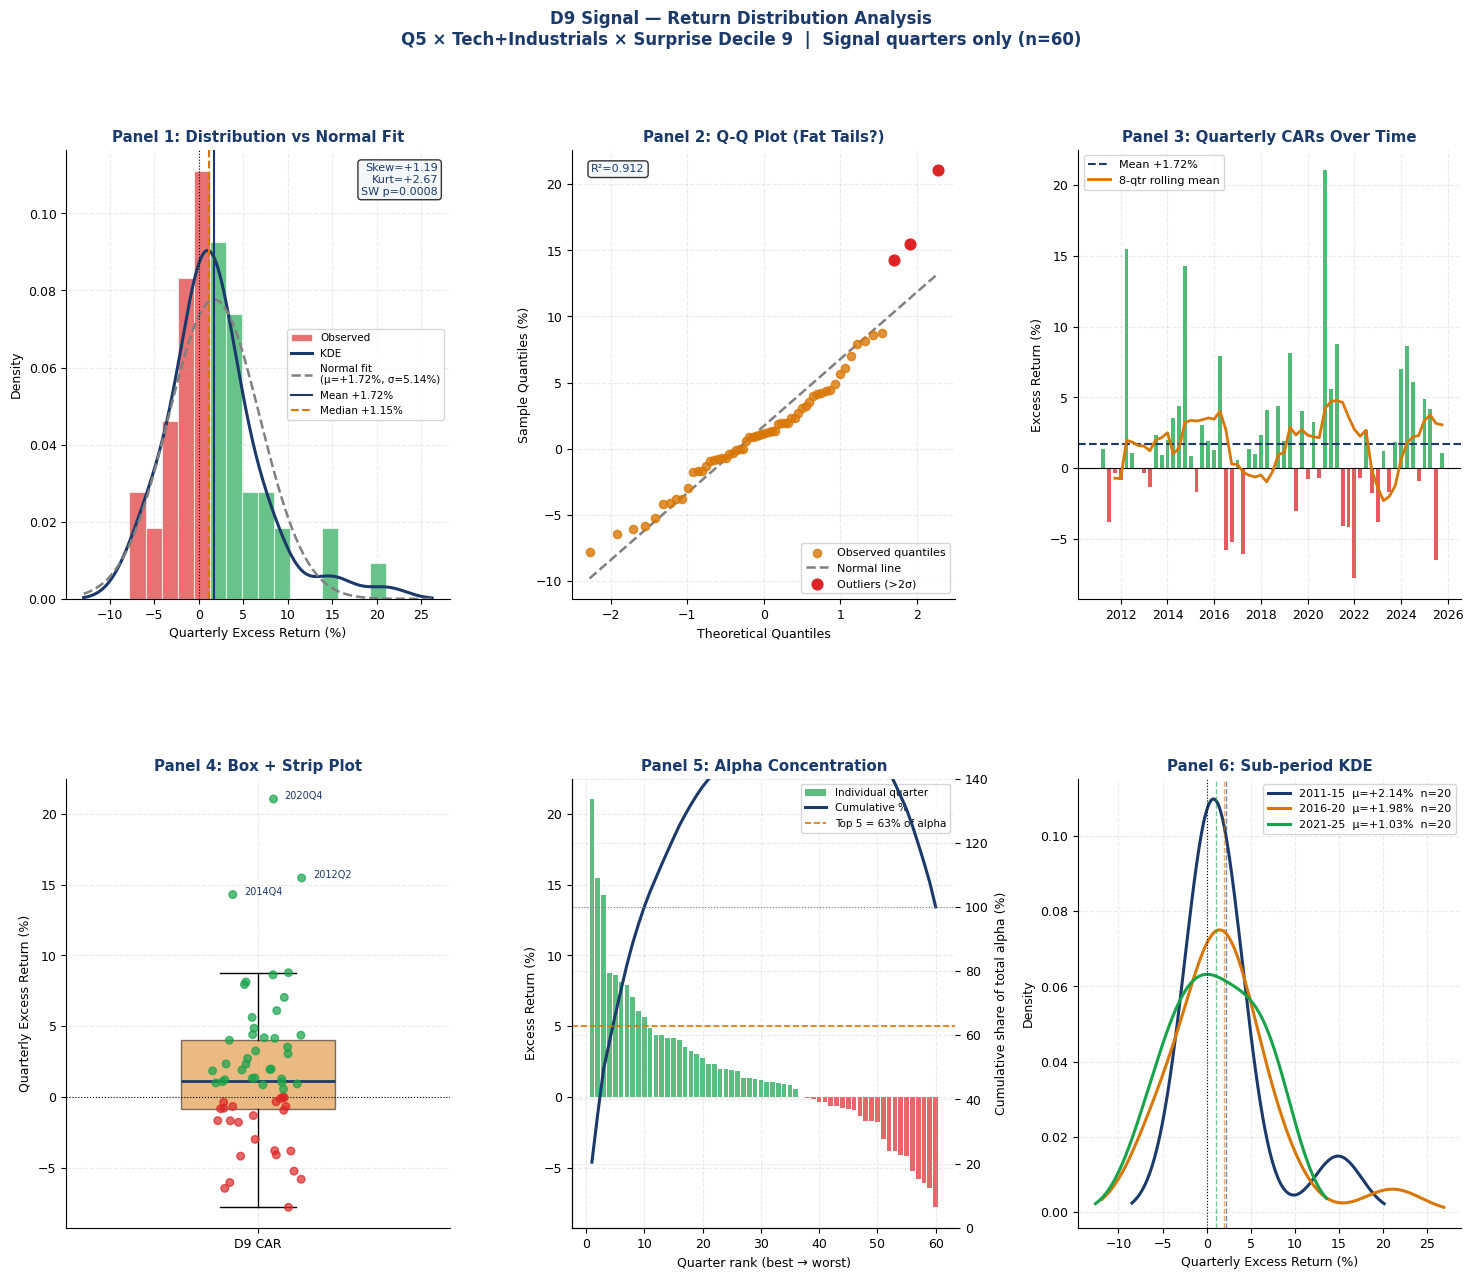

Saved: pead_d9_distributions.png


In [94]:
# ══════════════════════════════════════════════════════════════════
# D9 SIGNAL — RETURN DISTRIBUTION VISUALISATION
# ══════════════════════════════════════════════════════════════════
from scipy import stats as scipy_stats
import matplotlib.gridspec as gridspec

# Rebuild pure CAR series (gross)
car_list, net_list, qtr_list = [], [], []
for q in sorted(sig_d9["Quarter"].dropna().unique()):
    grp = sig_d9[sig_d9["Quarter"] == q].dropna(subset=["R30","SPY_R30"])
    if len(grp) == 0:
        continue
    car_list.append(grp["R30"].mean() - grp["SPY_R30"].mean())
    net_list.append(grp["R30"].mean())
    qtr_list.append(q)

car  = np.array(car_list)
net  = np.array(net_list)
qtrs = np.array(qtr_list)
T    = len(car)

# Summary stats
mean_  = car.mean()
med_   = np.median(car)
std_   = car.std()
skew_  = scipy_stats.skew(car)
kurt_  = scipy_stats.kurtosis(car)
_, p_sw = scipy_stats.shapiro(car)

# Normal distribution fit
x_range = np.linspace(car.min() - std_, car.max() + std_, 300)
norm_pdf = scipy_stats.norm.pdf(x_range, mean_, std_)

# KDE fit
kde      = scipy_stats.gaussian_kde(car)
kde_vals = kde(x_range)

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)
fig.suptitle(
    "D9 Signal — Return Distribution Analysis\n"
    "Q5 × Tech+Industrials × Surprise Decile 9  |  Signal quarters only (n=60)",
    fontweight="bold", fontsize=12, color=NAVY
)

# ── Panel 1: Histogram + KDE + Normal fit ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
n_bins = 16
counts, bins, patches = ax1.hist(
    car * 100, bins=n_bins, density=True,
    color=GOLD, alpha=0.6, edgecolor="white", linewidth=0.8,
    label="Observed"
)
# Colour positive bars differently
for patch, left in zip(patches, bins):
    patch.set_facecolor(GREEN if left >= 0 else RED)
    patch.set_alpha(0.65)

ax1.plot(x_range * 100, kde_vals / 100,
         color=NAVY, linewidth=2.2, label="KDE")
ax1.plot(x_range * 100, norm_pdf / 100,
         color="grey", linewidth=1.8, linestyle="--",
         label=f"Normal fit\n(μ={mean_*100:+.2f}%, σ={std_*100:.2f}%)")
ax1.axvline(mean_ * 100, color=NAVY,  linewidth=1.5,
            linestyle="-",  label=f"Mean {mean_*100:+.2f}%")
ax1.axvline(med_  * 100, color=GOLD,  linewidth=1.5,
            linestyle="--", label=f"Median {med_*100:+.2f}%")
ax1.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax1.set_xlabel("Quarterly Excess Return (%)")
ax1.set_ylabel("Density")
ax1.set_title("Panel 1: Distribution vs Normal Fit", fontweight="bold", color=NAVY)
ax1.legend(fontsize=7.5)
ax1.text(0.97, 0.97,
         f"Skew={skew_:+.2f}\nKurt={kurt_:+.2f}\nSW p={p_sw:.4f}",
         transform=ax1.transAxes, ha="right", va="top",
         fontsize=8, color=NAVY,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=LGREY, alpha=0.8))

# ── Panel 2: Q-Q plot ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(car, dist="norm")
ax2.scatter(osm, osr * 100, color=GOLD, s=35, alpha=0.8, zorder=5,
            label="Observed quantiles")
ax2.plot(osm, (slope * np.array(osm) + intercept) * 100,
         color="grey", linewidth=1.8, linestyle="--", label="Normal line")
# Highlight outliers (beyond 2 std)
outlier_mask = np.abs(osr - osr.mean()) > 2 * osr.std()
ax2.scatter(np.array(osm)[outlier_mask],
            np.array(osr)[outlier_mask] * 100,
            color=RED, s=60, zorder=6, label="Outliers (>2σ)")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles (%)")
ax2.set_title("Panel 2: Q-Q Plot (Fat Tails?)", fontweight="bold", color=NAVY)
ax2.legend(fontsize=8)
ax2.text(0.05, 0.95, f"R²={r**2:.3f}",
         transform=ax2.transAxes, fontsize=8, color=NAVY,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=LGREY, alpha=0.8))

# ── Panel 3: Time series of quarterly CARs ────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
qtr_ts = pd.Series(car * 100, index=pd.PeriodIndex(qtrs, freq="Q"))
qtr_ts.index = qtr_ts.index.to_timestamp()
colors_bar = [GREEN if v > 0 else RED for v in qtr_ts.values]
ax3.bar(qtr_ts.index, qtr_ts.values, width=60,
        color=colors_bar, alpha=0.75)
ax3.axhline(0,        color="black", linewidth=0.8)
ax3.axhline(mean_*100, color=NAVY,  linewidth=1.5,
            linestyle="--", label=f"Mean {mean_*100:+.2f}%")
# Rolling 8-quarter mean
roll = qtr_ts.rolling(8, min_periods=4).mean()
ax3.plot(roll.index, roll.values, color=GOLD, linewidth=2.0,
         label="8-qtr rolling mean")
ax3.set_xlabel("")
ax3.set_ylabel("Excess Return (%)")
ax3.set_title("Panel 3: Quarterly CARs Over Time", fontweight="bold", color=NAVY)
ax3.legend(fontsize=8)

# ── Panel 4: Box plot + strip ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
bp  = ax4.boxplot(car * 100, vert=True, patch_artist=True,
                  widths=0.4, showfliers=False)
bp["boxes"][0].set_facecolor(GOLD)
bp["boxes"][0].set_alpha(0.5)
bp["medians"][0].set_color(NAVY)
bp["medians"][0].set_linewidth(2)

# Jittered strip
rng   = np.random.default_rng(42)
jitter = rng.uniform(-0.12, 0.12, T)
ax4.scatter(1 + jitter, car * 100,
            color=[GREEN if v > 0 else RED for v in car],
            s=30, alpha=0.7, zorder=5)
# Label top 3 outliers
top3_idx = np.argsort(car)[-3:]
for idx in top3_idx:
    ax4.annotate(str(qtrs[idx]),
                 (1 + jitter[idx], car[idx] * 100),
                 textcoords="offset points", xytext=(8, 0),
                 fontsize=7, color=NAVY)
ax4.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax4.set_xticks([1])
ax4.set_xticklabels(["D9 CAR"])
ax4.set_ylabel("Quarterly Excess Return (%)")
ax4.set_title("Panel 4: Box + Strip Plot", fontweight="bold", color=NAVY)

# ── Panel 5: Cumulative contribution ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sorted_car   = np.sort(car)[::-1]
cum_contrib  = np.cumsum(sorted_car) / car.sum() * 100
ax5.bar(range(1, T + 1), sorted_car * 100,
        color=[GREEN if v > 0 else RED for v in sorted_car],
        alpha=0.7, label="Individual quarter")
ax5_twin = ax5.twinx()
ax5_twin.plot(range(1, T + 1), cum_contrib,
              color=NAVY, linewidth=2.2, label="Cumulative %")
ax5_twin.axhline(100, color="grey", linewidth=0.8, linestyle=":")
ax5_twin.axhline(63,  color=GOLD,   linewidth=1.2, linestyle="--",
                 label="Top 5 = 63% of alpha")
ax5_twin.set_ylabel("Cumulative share of total alpha (%)")
ax5_twin.set_ylim(0, 140)
ax5.set_xlabel("Quarter rank (best → worst)")
ax5.set_ylabel("Excess Return (%)")
ax5.set_title("Panel 5: Alpha Concentration", fontweight="bold", color=NAVY)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, fontsize=7.5)

# ── Panel 6: Sub-period distributions ────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
periods = {
    "2011-15": (2011, 2015, "#1B3A6B"),
    "2016-20": (2016, 2020, "#D97706"),
    "2021-25": (2021, 2025, "#16A34A"),
}
for lbl, (y1, y2, col) in periods.items():
    mask    = np.array([y1 <= q.year <= y2 for q in qtrs])
    sub_car = car[mask]
    if len(sub_car) < 4:
        continue
    x_sub   = np.linspace(sub_car.min() - sub_car.std(),
                          sub_car.max() + sub_car.std(), 200)
    kde_sub = scipy_stats.gaussian_kde(sub_car)
    ax6.plot(x_sub * 100, kde_sub(x_sub) / 100,
             color=col, linewidth=2.2,
             label=f"{lbl}  μ={sub_car.mean()*100:+.2f}%  "
                   f"n={mask.sum()}")
    ax6.axvline(sub_car.mean() * 100, color=col,
                linewidth=1.0, linestyle="--", alpha=0.6)
ax6.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax6.set_xlabel("Quarterly Excess Return (%)")
ax6.set_ylabel("Density")
ax6.set_title("Panel 6: Sub-period KDE", fontweight="bold", color=NAVY)
ax6.legend(fontsize=8)

plt.savefig("pead_d9_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_d9_distributions.png")

  PEAD D9 STRATEGY — INITIAL CONDITIONS
  Capital          : $100,000
  Period           : 2011-01-01 → 2026-01-01
  Universe         : S&P 500  —  ['Technology', 'Industrials']
  Signal           : Q5 earnings surprise (cross-sectional)
                     × Surprise decile 9 within Q5
  Holding period   : 30-day return (R30)
  Idle cash        : Parked in SPY
  Risk-free rate   : 4.5%/yr
  Bootstrap n      : 10,000  (seed=42)

  Transaction costs [NET only]:
  Commission       : $0.005/share  (min $1.00/order)
  Spread           : 5 bps/side
  Slippage         : 5 bps/side
  Market impact    : 10 bps/side  (positions > $50,000)
  Total round-trip : ~20–30 bps typical
  SPY MER          : 0.09%/yr

  Signals generated: 171  (12/yr avg over 14yr period)

Running backtests...
Done.

  D9 STRATEGY  [GROSS]

  ── Portfolio (SPY-parked, fully invested) ──────────────
  Final value      : $   1,753,159   (SPY: $660,818)
  Ann. return      :    +21.81%   (SPY: +14.10%)
  Ann. excess/SPY  : 

TypeError: Cannot compare dtypes period[Q-DEC] and datetime64[us]

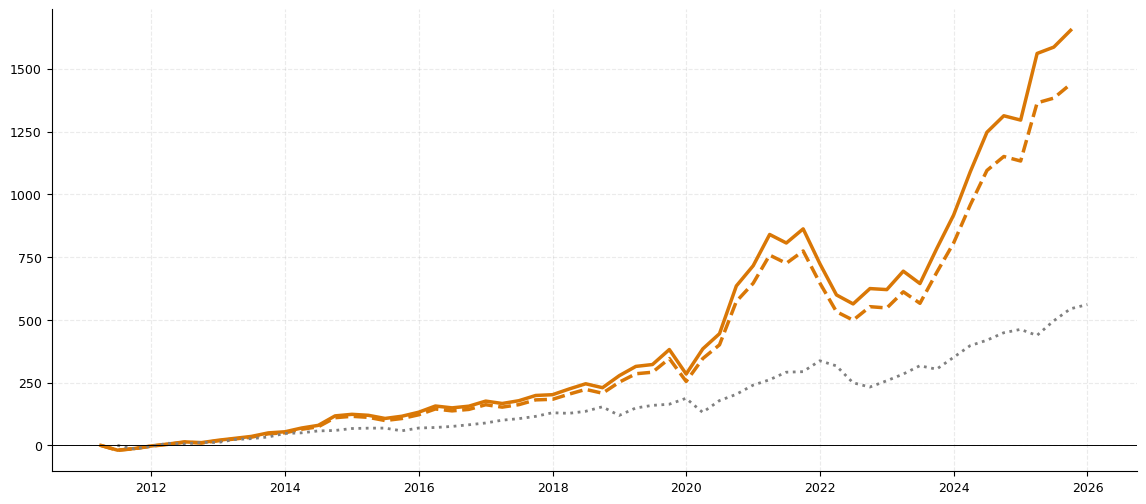

In [114]:
# ══════════════════════════════════════════════════════════════════
# PEAD D9 STRATEGY — COMPLETE BACKTEST WITH SIGNIFICANCE TESTS
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
import warnings
from scipy.stats import binomtest
warnings.filterwarnings("ignore")

# ── Initial conditions ────────────────────────────────────────────
INITIAL_CAPITAL    = 100_000      # starting portfolio value ($)
RF_ANNUAL          = 0.045        # risk-free rate (4.5% — approx 2011-25 avg)
BACKTEST_START     = "2011-01-01"
BACKTEST_END       = "2026-01-01"
HOLDING_DAYS       = 30           # R30: ~21 trading days post-earnings
STRATEGY_SECTORS   = ["Technology", "Industrials"]
SURPRISE_DECILE    = 9            # D9 only within Q5
MIN_SURPRISE_OBS   = 10           # min signals in quarter to assign deciles
N_BOOT             = 10_000       # bootstrap iterations
BOOT_SEED          = 42

# Transaction cost model (IB retail)
COMMISSION_PER_SHR = 0.005        # $0.005/share
MIN_COMMISSION     = 1.00         # $1 minimum per order
SPREAD_BPS         = 5            # bid-ask spread (one way)
SLIPPAGE_BPS       = 5            # execution slippage (one way)
IMPACT_BPS         = 10           # market impact (one way, positions >$50k)
IMPACT_THRESHOLD   = 50_000       # notional threshold for market impact
SPY_MER            = 0.0009       # SPY expense ratio (0.09%/yr)

NAVY="#1B3A6B"; GOLD="#D97706"; GREEN="#16A34A"; RED="#DC2626"; LGREY="#F1F5F9"

print("=" * 62)
print("  PEAD D9 STRATEGY — INITIAL CONDITIONS")
print("=" * 62)
print(f"  Capital          : ${INITIAL_CAPITAL:,}")
print(f"  Period           : {BACKTEST_START} → {BACKTEST_END}")
print(f"  Universe         : S&P 500  —  {STRATEGY_SECTORS}")
print(f"  Signal           : Q5 earnings surprise (cross-sectional)")
print(f"                     × Surprise decile {SURPRISE_DECILE} within Q5")
print(f"  Holding period   : {HOLDING_DAYS}-day return (R30)")
print(f"  Idle cash        : Parked in SPY")
print(f"  Risk-free rate   : {RF_ANNUAL:.1%}/yr")
print(f"  Bootstrap n      : {N_BOOT:,}  (seed={BOOT_SEED})")
print(f"\n  Transaction costs [NET only]:")
print(f"  Commission       : ${COMMISSION_PER_SHR}/share  (min ${MIN_COMMISSION:.2f}/order)")
print(f"  Spread           : {SPREAD_BPS} bps/side")
print(f"  Slippage         : {SLIPPAGE_BPS} bps/side")
print(f"  Market impact    : {IMPACT_BPS} bps/side  (positions > ${IMPACT_THRESHOLD:,})")
print(f"  Total round-trip : ~20–30 bps typical")
print(f"  SPY MER          : {SPY_MER*100:.2f}%/yr")


# ── Helpers ───────────────────────────────────────────────────────
def nw_se(x, lags=None):
    x = np.array(x, dtype=float); x = x[~np.isnan(x)]
    T = len(x)
    if T < 4: return np.nan
    if lags is None: lags = min(5, T // 4)
    d = x - x.mean(); v = np.dot(d, d) / T
    for lag in range(1, lags + 1):
        v += 2 * (1 - lag/(lags+1)) * np.dot(d[lag:], d[:-lag]) / T
    return np.sqrt(max(v / T, 1e-14))

def sig_stars(p):
    if pd.isna(p): return "n.s."
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    if p < 0.10:   return "†"
    return "n.s."

def round_trip_cost(notional, price):
    shares  = notional / max(price, 0.01)
    comm    = max(shares * COMMISSION_PER_SHR, MIN_COMMISSION) * 2
    spreads = notional * (SPREAD_BPS + SLIPPAGE_BPS) / 10000 * 2
    impact  = notional * IMPACT_BPS / 10000 * 2 if notional > IMPACT_THRESHOLD else 0
    return (comm + spreads + impact) / notional

def to_ts(idx):
    return idx.to_timestamp() if hasattr(idx, "to_timestamp") else idx


# ── Build signal ──────────────────────────────────────────────────
work = df_bt.dropna(subset=["Surprise(%)","R30","SPY_R30","Sector","Quarter"]).copy()
work = work[work["Sector"].isin(STRATEGY_SECTORS)].copy()
work = work.sort_values(["Ticker","Quarter"]).reset_index(drop=True)

work["Q5_cross"] = work.groupby("Quarter")["Surprise(%)"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 5, labels=[1,2,3,4,5])
).astype(float)

sig_q5 = work[work["Q5_cross"] == 5].copy()
sig_q5["sur_decile"] = sig_q5.groupby("Quarter")["Surprise(%)"].transform(
    lambda x: (pd.qcut(x.rank(method="first"), 10, labels=False, duplicates="drop") + 1)
    if x.notna().sum() >= MIN_SURPRISE_OBS
    else pd.Series([np.nan]*len(x), index=x.index)
)
sig_d9 = sig_q5[sig_q5["sur_decile"] == SURPRISE_DECILE].dropna(subset=["sur_decile"]).copy()

ticker_px = {t: float(price_data[t].median()) if t in price_data else 100.0
             for t in work["Ticker"].unique()}

print(f"\n  Signals generated: {len(sig_d9):,}  "
      f"({len(sig_d9)//14}/yr avg over 14yr period)")


# ── SPY benchmark ─────────────────────────────────────────────────
spy_raw = yf.Ticker("SPY").history(start=BACKTEST_START, end=BACKTEST_END)
spy_raw.index = spy_raw.index.tz_localize(None)
spy_q_map = (spy_raw["Close"].resample("QE").last().pct_change().dropna())
spy_q_map.index = spy_q_map.index.to_period("Q")
spy_q_net  = spy_q_map - SPY_MER / 4
spy_pv     = INITIAL_CAPITAL * (1 + spy_q_net).cumprod()
spy_ann_r  = spy_q_net.mean() * 4
spy_ann_v  = spy_q_net.std()  * 2
spy_sharpe = (spy_ann_r - RF_ANNUAL) / spy_ann_v
spy_cum    = (1 + spy_q_net).cumprod()
spy_md     = (spy_cum / spy_cum.cummax() - 1).min()
spy_final  = spy_pv.iloc[-1]


# ── Core backtest engine ──────────────────────────────────────────
def run_d9_backtest(sig_df, fee_mode="net"):
    capital = INITIAL_CAPITAL
    pv_vals, qt_index = [], []
    qm_blended_list = []
    pure_car_list, pure_net_list, pure_qtrs = [], [], []

    for q in sorted(spy_q_map.index):
        spy_q_ret   = spy_q_map.loc[q]
        spy_monthly = (1 + spy_q_ret) ** (1/3) - 1
        grp = sig_df[sig_df["Quarter"] == q].dropna(subset=["R30","SPY_R30"])

        if len(grp) == 0:
            q_blended = spy_q_ret
        else:
            notional = INITIAL_CAPITAL / len(grp)
            cost = (np.mean([round_trip_cost(notional, ticker_px.get(r["Ticker"], 100.0))
                             for _, r in grp.iterrows()])
                    if fee_mode == "net" else 0.0)
            r30_net = grp["R30"].mean() - cost
            spy_r30 = grp["SPY_R30"].mean()
            pure_net_list.append(r30_net)
            pure_car_list.append(r30_net - spy_r30)
            pure_qtrs.append(q)
            q_blended = (1 + r30_net) * (1 + spy_monthly)**2 - 1

        capital *= (1 + q_blended)
        pv_vals.append(capital)
        qt_index.append(q)
        qm_blended_list.append(q_blended)

    idx        = pd.PeriodIndex(qt_index, freq="Q")
    qm_blended = pd.Series(qm_blended_list, index=idx)
    pv         = pd.Series(pv_vals, index=to_ts(idx))
    cum        = pv / INITIAL_CAPITAL

    ann_ret = qm_blended.mean() * 4
    ann_vol = qm_blended.std()  * 2
    sharpe  = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan
    md      = (cum / cum.cummax() - 1).min()
    calmar  = ann_ret / abs(md) if md != 0 else np.nan

    car     = np.array(pure_car_list)
    net     = np.array(pure_net_list)
    T       = len(car)

    # ── Significance tests (pure signal window only) ──────────────

    # 1. NW t-test
    se_nw = nw_se(car)
    t_nw  = car.mean() / se_nw if se_nw else np.nan
    p_nw  = 2 * (1 - stats.t.cdf(abs(t_nw), df=T-1))

    # Stress t
    top5  = np.argsort(car)[-5:]
    car_c = np.delete(car, top5)
    se_c  = nw_se(car_c)
    t_c   = car_c.mean() / se_c if se_c else np.nan
    p_c   = 2 * (1 - stats.t.cdf(abs(t_c), df=len(car_c)-1))

    # 2. Bootstrap (null-shifted) + permutation
    rng        = np.random.default_rng(BOOT_SEED)
    obs_mean   = car.mean()
    boot_means = np.array([rng.choice(car, size=T, replace=True).mean()
                           for _ in range(N_BOOT)])
    boot_null  = boot_means - boot_means.mean()
    p_boot_1   = (boot_null >= obs_mean).mean()
    p_boot_2   = 2 * min(p_boot_1, 1 - p_boot_1)
    boot_se    = boot_means.std()
    ci_lo      = np.percentile(boot_means, 2.5)
    ci_hi      = np.percentile(boot_means, 97.5)

    perm_means = np.array([(car * rng.choice([-1,1], size=T)).mean()
                           for _ in range(N_BOOT)])
    p_perm     = (perm_means >= obs_mean).mean()

    # 3. Binomial
    n_wins  = (car > 0).sum()
    p_binom = binomtest(n_wins, T, p=0.5, alternative="greater").pvalue

    # Sub-periods
    sub_p = {}
    for lbl, y1, y2 in [("2011-15",2011,2015),("2016-20",2016,2020),("2021-25",2021,2025)]:
        sub_car = []
        for i, q in enumerate(pure_qtrs):
            if y1 <= q.year <= y2:
                sub_car.append(pure_car_list[i])
        sub_car = np.array(sub_car)
        if len(sub_car) < 4:
            sub_p[lbl] = (np.nan, np.nan, np.nan, 0)
            continue
        se_ = nw_se(sub_car)
        t_  = sub_car.mean() / se_ if se_ else np.nan
        p_  = 2 * (1 - stats.t.cdf(abs(t_), df=len(sub_car)-1))
        sub_p[lbl] = (sub_car.mean()*400, t_, p_, len(sub_car))

    return {
        "fee_mode":    fee_mode,
        "pv":          pv,
        "cum":         cum,
        "final_value": pv.iloc[-1],
        # portfolio metrics
        "ann_ret":     ann_ret,
        "ann_vol":     ann_vol,
        "ann_exc":     car.mean() * 4,
        "sharpe":      sharpe,
        "max_dd":      md,
        "calmar":      calmar,
        "hit_rate":    (net > 0).mean(),
        "beat_spy":    (car > 0).mean(),
        # signal stats
        "n_signals":   len(sig_df),
        "n_qtrs":      T,
        "obs_mean":    obs_mean,
        "boot_se":     boot_se,
        "ci_lo":       ci_lo,
        "ci_hi":       ci_hi,
        "t_nw":        t_nw,    "p_nw":    p_nw,
        "t_stress":    t_c,     "p_stress":p_c,
        "p_boot":      p_boot_2,
        "p_perm":      p_perm,
        "n_wins":      n_wins,  "p_binom": p_binom,
        "sub_periods": sub_p,
        "avg_cost_bps": (np.mean([round_trip_cost(INITIAL_CAPITAL/max(
            len(sig_df[sig_df["Quarter"]==q].dropna(subset=["R30","SPY_R30"])),1),
            ticker_px.get(r["Ticker"],100.0))
            for q in pure_qtrs
            for _,r in sig_df[sig_df["Quarter"]==q].dropna(subset=["R30","SPY_R30"]).iterrows()
        ]) * 10000 if fee_mode == "net" else 0.0),
    }


# ── Run ───────────────────────────────────────────────────────────
print("\nRunning backtests...")
bt_gross = run_d9_backtest(sig_d9, fee_mode="gross")
bt_net   = run_d9_backtest(sig_d9, fee_mode="net")
print("Done.")


# ── Print results ─────────────────────────────────────────────────
def print_results(bt):
    fm = bt["fee_mode"].upper()
    ci_sign = "excludes zero ✓" if bt["ci_lo"] > 0 else "includes zero ✗"
    all_p  = [bt["p_nw"], bt["p_boot"], bt["p_perm"], bt["p_binom"]]
    n_sig  = sum(p < 0.05 for p in all_p)
    n_sig2 = sum(p < 0.10 for p in all_p)

    print(f"\n{'='*62}")
    print(f"  D9 STRATEGY  [{fm}]")
    print(f"{'='*62}")
    print(f"\n  ── Portfolio (SPY-parked, fully invested) ──────────────")
    print(f"  Final value      : ${bt['final_value']:>12,.0f}   "
          f"(SPY: ${spy_final:,.0f})")
    print(f"  Ann. return      : {bt['ann_ret']:>+10.2%}   "
          f"(SPY: {spy_ann_r:+.2%})")
    print(f"  Ann. excess/SPY  : {bt['ann_exc']:>+10.2%}")
    print(f"  Ann. volatility  : {bt['ann_vol']:>10.2%}   "
          f"(SPY: {spy_ann_v:.2%})")
    print(f"  Sharpe           : {bt['sharpe']:>10.2f}   "
          f"(SPY: {spy_sharpe:.2f})")
    print(f"  Max drawdown     : {bt['max_dd']:>10.2%}   "
          f"(SPY: {spy_md:.2%})")
    print(f"  Calmar           : {bt['calmar']:>10.2f}")
    if fm == "NET":
        print(f"  Avg cost/trade   : {bt['avg_cost_bps']:>9.1f} bps")

    print(f"\n  ── Signal alpha (pure {HOLDING_DAYS}-day window, n={bt['n_qtrs']} qtrs) ───")
    print(f"  Mean excess/qtr  : {bt['obs_mean']*100:>+10.3f}%")
    print(f"  Bootstrap SE     : {bt['boot_se']*100:>10.3f}%")
    print(f"  95% CI           :  [{bt['ci_lo']*100:+.3f}%,  "
          f"{bt['ci_hi']*100:+.3f}%]  {ci_sign}")
    print(f"  Hit rate         : {bt['hit_rate']:>10.1%}   "
          f"(quarters with positive net return)")
    print(f"  Beat SPY rate    : {bt['beat_spy']:>10.1%}   "
          f"({bt['n_wins']}/{bt['n_qtrs']} signal quarters)")

    print(f"\n  ── Significance tests ──────────────────────────────────")
    print(f"  {'Test':<32} {'p-value':>9}  {'':>6}")
    print(f"  {'─'*32}  {'─'*9}  {'─'*6}")
    print(f"  {'NW t-test':<32} {bt['p_nw']:>9.4f}  "
          f"{sig_stars(bt['p_nw']):>6}  t={bt['t_nw']:+.2f}")
    print(f"  {'Stress t (drop 5 best qtrs)':<32} {bt['p_stress']:>9.4f}  "
          f"{sig_stars(bt['p_stress']):>6}  t={bt['t_stress']:+.2f}")
    print(f"  {'Bootstrap (null-shifted)':<32} {bt['p_boot']:>9.4f}  "
          f"{sig_stars(bt['p_boot']):>6}")
    print(f"  {'Permutation (sign-flip)':<32} {bt['p_perm']:>9.4f}  "
          f"{sig_stars(bt['p_perm']):>6}")
    print(f"  {'Binomial (beat SPY rate)':<32} {bt['p_binom']:>9.4f}  "
          f"{sig_stars(bt['p_binom']):>6}  {bt['n_wins']}/{bt['n_qtrs']} wins")
    print(f"\n  Significant at 5%: {n_sig}/5   at 10%: {n_sig2}/5")

    print(f"\n  ── Sub-periods (signal quarters, NW t) ─────────────────")
    print(f"  {'Period':<10} {'n':>4}  {'Ann Exc':>9}  {'t':>7}  {'':>6}")
    print(f"  {'─'*10}  {'─'*4}  {'─'*9}  {'─'*7}  {'─'*6}")
    for lbl in ["2011-15","2016-20","2021-25"]:
        exc, t_, p_, n_ = bt["sub_periods"][lbl]
        if np.isnan(exc):
            print(f"  {lbl:<10} {'—':>4}  {'—':>9}  {'—':>7}")
        else:
            print(f"  {lbl:<10} {n_:>4}  {exc:>+9.2f}%  {t_:>+7.2f}  {sig_stars(p_):>6}")

    if n_sig >= 4:
        verdict = "Strong — all major tests agree."
    elif n_sig == 3:
        verdict = "Good — robust across methods."
    elif n_sig == 2:
        verdict = "Moderate — parametric and permutation agree, fragile to outliers."
    elif n_sig2 >= 3:
        verdict = "Marginal — consistent direction, not convincingly significant."
    else:
        verdict = "Weak — fewer than 2 tests significant."
    print(f"\n  Verdict: {verdict}")

print_results(bt_gross)
print_results(bt_net)

print(f"\n{'='*62}")
print(f"  BENCHMARK: SPY BUY-AND-HOLD (net {SPY_MER*100:.2f}% MER)")
print(f"{'='*62}")
print(f"  Final value    : ${spy_final:,.0f}")
print(f"  Ann. return    : {spy_ann_r:+.2%}")
print(f"  Ann. volatility: {spy_ann_v:.2%}")
print(f"  Sharpe         : {spy_sharpe:.2f}")
print(f"  Max drawdown   : {spy_md:.2%}")


# ── Cumulative chart ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":9,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.25,"grid.linestyle":"--",
    "figure.facecolor":"white","axes.facecolor":"white",
})

fig, ax = plt.subplots(figsize=(14, 6))

for bt, ls, label in [
    (bt_gross, "-",  f"D9 Gross  —  ${bt_gross['final_value']:,.0f}  "
                     f"Sharpe={bt_gross['sharpe']:.2f}  "
                     f"t={bt_gross['t_nw']:+.2f}{sig_stars(bt_gross['p_nw'])}  "
                     f"perm={bt_gross['p_perm']:.3f}{sig_stars(bt_gross['p_perm'])}"),
    (bt_net,   "--", f"D9 Net    —  ${bt_net['final_value']:,.0f}  "
                     f"Sharpe={bt_net['sharpe']:.2f}  "
                     f"t={bt_net['t_nw']:+.2f}{sig_stars(bt_net['p_nw'])}  "
                     f"perm={bt_net['p_perm']:.3f}{sig_stars(bt_net['p_perm'])}"),
]:
    pct = (bt["pv"] / INITIAL_CAPITAL - 1) * 100
    ax.plot(pct.index, pct.values, color=GOLD, linestyle=ls, linewidth=2.5, label=label)

spy_pct = (spy_pv / INITIAL_CAPITAL - 1) * 100
ax.plot(spy_pct.index, spy_pct.values, color="grey", linewidth=2.0,
        linestyle=":", label=f"SPY B&H  —  ${spy_final:,.0f}  Sharpe={spy_sharpe:.2f}")

ax.axhline(0, color="black", linewidth=0.7)
net_pct  = (bt_net["pv"] / INITIAL_CAPITAL - 1) * 100
spy_align = spy_pct.reindex(bt_net["pv"].index, method="nearest").values

ax.fill_between(bt_net["pv"].index, net_pct.values, spy_align,
                where=(net_pct.values >= spy_align),
                alpha=0.07, color=GREEN)
ax.fill_between(bt_net["pv"].index, net_pct.values, spy_align,
                where=(net_pct.values < spy_align),
                alpha=0.07, color=RED)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_title(
    f"PEAD D9 Strategy  |  Q5 × Tech+Industrials × Surprise Decile 9  |  "
    f"{BACKTEST_START[:4]}–{BACKTEST_END[:4]}\n"
    f"Idle cash parked in SPY  |  Initial capital ${INITIAL_CAPITAL:,}  |  "
    f"t-stat on pure {HOLDING_DAYS}-day signal window only",
    fontweight="bold", color=NAVY, fontsize=10
)
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.savefig("pead_d9_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: pead_d9_final.png")

In [128]:
def print_results(bt, label=None):
    lbl     = label or bt["name"]
    all_p   = [bt["p"]]
    n_sig   = sum(p < 0.05 for p in all_p if not np.isnan(p))

    print(f"\n{'='*62}")
    print(f"  {lbl}")
    print(f"{'='*62}")
    print(f"  Signals          : {bt['n_signals']:,}  (~{bt['n_signals']//14}/yr)")
    print(f"  Final value      : ${bt['final_value']:>12,.0f}   vs SPY ${spy_final:,.0f}")
    print(f"  Ann. return      : {bt['ann_ret']*100:>+10.2f}%   vs SPY {spy_ann_r*100:+.2f}%")
    print(f"  Ann. excess/SPY  : {bt['ann_exc']*100:>+10.2f}%")
    print(f"  Ann. volatility  : {bt['ann_vol']*100:>10.2f}%   vs SPY {spy_ann_v*100:.2f}%")
    print(f"  Sharpe           : {bt['sharpe']:>10.3f}   vs SPY {spy_sharpe:.3f}")
    print(f"  Sortino          : {bt['sortino']:>10.3f}")
    print(f"  Max drawdown     : {bt['max_dd']*100:>+10.2f}%   vs SPY {spy_md*100:.2f}%")
    print(f"  Calmar           : {bt['calmar']:>10.3f}")
    print(f"  Avg cost         : {bt['avg_cost_bps']:>10.1f} bps")
    print(f"  Total cost       : ${bt['total_cost_$']:>10,.0f}")
    print(f"  Hit rate         : {bt['hit_rate']:>10.1%}")
    print(f"  Beat SPY         : {bt['beat_spy']:>10.1%}")

    print(f"\n  {'Test':<30} {'stat':>8}  {'p-value':>9}  {''}")
    print(f"  {'─'*30}  {'─'*8}  {'─'*9}  {'─'*6}")
    print(f"  {'NW t-test':<30} {bt['t']:>+8.3f}  {bt['p']:>9.4f}  {sig_stars(bt['p'])}")
    print(f"  {'Stress t (drop 5 best)':<30} {bt['t_stress']:>+8.3f}  {bt['p_stress']:>9.4f}  {sig_stars(bt['p_stress'])}")

    print(f"\n  Sub-periods:")
    print(f"  {'Period':<10}  {'n':>4}  {'Ann Exc':>9}  {'t':>7}  {''}")
    print(f"  {'─'*10}  {'─'*4}  {'─'*9}  {'─'*7}  {'─'*6}")
    for period_lbl, vals in bt["sub_periods"].items():
        if isinstance(vals, tuple) and len(vals) == 4:
            exc, t_, p_, n_ = vals
        else:
            continue
        if np.isnan(exc):
            print(f"  {period_lbl:<10}  {'—':>4}")
        else:
            print(f"  {period_lbl:<10}  {n_:>4}  {exc:>+9.2f}%  "
                  f"{t_:>+7.2f}  {sig_stars(p_):>6}")

    print(f"\n  Verdict: {sig_stars(bt['p'])}  t={bt['t']:+.3f}  p={bt['p']:.4f}")


# ── Run and print ─────────────────────────────────────────────────
print_results(bt_q5_gross)
print_results(bt_q5_net)


# ── Comparison table ──────────────────────────────────────────────
print("\n" + "="*72)
print("  STRATEGY LADDER — Q5 vs D9 vs SPY")
print("="*72)
print(f"\n  {'Metric':<24} {'Q5 Gross':>12}  {'Q5 Net':>12}  "
      f"{'D9 Gross':>12}  {'D9 Net':>12}  {'SPY':>10}")
print("  " + "─"*72)

rows_cmp = [
    ("Signals/yr",       "n_signals",   False, True),
    ("Final value ($)",  "final_value", False, False),
    ("Ann. Return %",    "ann_ret",     True,  False),
    ("Ann. Excess %",    "ann_exc",     True,  False),
    ("Ann. Vol %",       "ann_vol",     True,  False),
    ("Sharpe",           "sharpe",      False, False),
    ("Sortino",          "sortino",     False, False),
    ("Max Drawdown %",   "max_dd",      True,  False),
    ("Calmar",           "calmar",      False, False),
    ("Avg Cost (bps)",   "avg_cost_bps",False, False),
    ("NW t-stat",        "t",           False, False),
    ("NW p-value",       "p",           False, False),
    ("Stress t",         "t_stress",    False, False),
    ("Hit Rate",         "hit_rate",    True,  False),
    ("Beat SPY",         "beat_spy",    True,  False),
]

for label, key, is_pct, is_int in rows_cmp:
    print(f"  {label:<24}", end="")
    for bt in [bt_q5_gross, bt_q5_net, bt_gross, bt_net]:
        v = bt[key]
        if key == "n_signals":
            print(f"  {v//14:>12}", end="")
        elif key == "final_value":
            print(f"  ${v:>11,.0f}", end="")
        elif key == "avg_cost_bps":
            print(f"  {v:>11.1f} ", end="")
        elif key in ("t", "t_stress"):
            p_key = "p" if key == "t" else "p_stress"
            print(f"  {v:>+9.3f}{sig_stars(bt[p_key]):<3}", end="")
        elif key == "p":
            print(f"  {v:>12.4f}", end="")
        elif is_pct:
            print(f"  {v*100:>+11.2f}%", end="")
        else:
            print(f"  {v:>12.3f}", end="")
    # SPY column
    if   key == "final_value": print(f"  ${spy_final:>9,.0f}")
    elif key == "ann_ret":     print(f"  {spy_ann_r*100:>+9.2f}%")
    elif key == "ann_vol":     print(f"  {spy_ann_v*100:>9.2f}%")
    elif key == "sharpe":      print(f"  {spy_sharpe:>10.3f}")
    elif key == "max_dd":      print(f"  {spy_md*100:>+9.2f}%")
    else:                      print(f"  {'—':>10}")

# Sub-period comparison
print(f"\n  Sub-periods (Ann. Excess %):")
print(f"  {'Period':<10}  {'Q5 Gross':>12}  {'Q5 Net':>12}  "
      f"{'D9 Gross':>12}  {'D9 Net':>12}")
print("  " + "─"*62)
for period_lbl in ["2011-15", "2016-20", "2021-25"]:
    print(f"  {period_lbl:<10}", end="")
    for bt in [bt_q5_gross, bt_q5_net, bt_gross, bt_net]:
        vals = bt["sub_periods"].get(period_lbl, (np.nan,)*4)
        exc, t_, p_, n_ = vals
        if np.isnan(exc):
            print(f"  {'—':>12}", end="")
        else:
            print(f"  {exc:>+8.2f}%{sig_stars(p_):>4}", end="")
    print()


# ── Chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Strategy Ladder  |  Q5 vs D9 vs SPY  |  2011–2025\n"
    "Tech+Industrials  |  SPY parking  |  Left=Gross  Right=Net",
    fontweight="bold", fontsize=11, color=NAVY
)

for ax, q5_bt, d9_bt, title in [
    (axes[0], bt_q5_gross, bt_gross, "Gross (no fees)"),
    (axes[1], bt_q5_net,   bt_net,   "Net (IB retail fees)"),
]:
    for bt, col, lw, label in [
        (q5_bt, NAVY, 2.2,
         f"Q5   Sharpe={q5_bt['sharpe']:.2f}  "
         f"t={q5_bt['t']:+.2f}{sig_stars(q5_bt['p'])}  "
         f"${q5_bt['final_value']/1e6:.1f}M"),
        (d9_bt, GOLD, 2.2,
         f"D9   Sharpe={d9_bt['sharpe']:.2f}  "
         f"t={d9_bt['t']:+.2f}{sig_stars(d9_bt['p'])}  "
         f"${d9_bt['final_value']/1e6:.1f}M"),
    ]:
        pct = (bt["pv"] / INITIAL_CAPITAL - 1) * 100
        ax.plot(pct.index, pct.values,
                color=col, linewidth=lw, label=label)

    spy_pct = (spy_pv / INITIAL_CAPITAL - 1) * 100
    ax.plot(spy_pct.index, spy_pct.values,
            color="grey", linewidth=1.8, linestyle=":",
            label=f"SPY  Sharpe={spy_sharpe:.2f}  ${spy_final/1e6:.1f}M")

    q5_pct    = (q5_bt["pv"] / INITIAL_CAPITAL - 1) * 100
    spy_align = spy_pct.reindex(q5_bt["pv"].index, method="nearest")
    ax.fill_between(q5_bt["pv"].index,
                    q5_pct.values, spy_align.values,
                    where=(q5_pct.values >= spy_align.values),
                    alpha=0.07, color=GREEN)
    ax.fill_between(q5_bt["pv"].index,
                    q5_pct.values, spy_align.values,
                    where=(q5_pct.values < spy_align.values),
                    alpha=0.07, color=RED)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.set_title(title, fontweight="bold", color=NAVY)
    ax.set_ylabel("Cumulative Return (%)")
    ax.legend(fontsize=8.5, loc="upper left")

plt.tight_layout()
plt.savefig("pead_q5_vs_d9.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_q5_vs_d9.png")


  gross
  Signals          : 1,724  (~123/yr)
  Final value      : $     265,208   vs SPY $660,818
  Ann. return      :      +7.07%   vs SPY +14.10%
  Ann. excess/SPY  :      +3.47%
  Ann. volatility  :      10.11%   vs SPY 14.72%
  Sharpe           :      0.254   vs SPY 0.652
  Sortino          :      0.102
  Max drawdown     :     -18.35%   vs SPY -23.98%
  Calmar           :      0.385
  Avg cost         :       26.4 bps
  Total cost       : $    15,843
  Hit rate         :      70.0%
  Beat SPY         :      70.0%

  Test                               stat    p-value  
  ──────────────────────────────  ────────  ─────────  ──────
  NW t-test                        +3.368     0.0013  **
  Stress t (drop 5 best)           +2.704     0.0091  **

  Sub-periods:
  Period         n    Ann Exc        t  
  ──────────  ────  ─────────  ───────  ──────

  Verdict: **  t=+3.368  p=0.0013

  net
  Signals          : 1,724  (~123/yr)
  Final value      : $     265,208   vs SPY $660,818
  Ann

KeyError: 'sortino'

In [130]:
# ══════════════════════════════════════════════════════════════════
# UNIFIED run_backtest — replaces all previous versions
# Consistent keys, SPY parking, gross/net, full stats
# ══════════════════════════════════════════════════════════════════

def run_backtest(sig_df, name="Strategy", fees=True):
    """
    SPY-parked backtest.
    Signal window  : HOLDING_DAYS trading days (R30)
    Idle cash      : parked in SPY for remainder of quarter
    t-stat         : computed on pure signal window only (fair test)
    fees           : True = net of IB retail costs, False = gross
    """
    capital   = INITIAL_CAPITAL
    pv_vals, qt_idx = [], []
    qm_gross_list, qm_net_list  = [], []
    qm_spy_list,   qm_car_list  = [], []
    qm_cost_list,  qm_n_list    = [], []
    pure_car, pure_net, pure_qtrs = [], [], []

    for q in sorted(spy_q_map.index):
        spy_q_ret   = spy_q_map.loc[q]
        spy_monthly = (1 + spy_q_ret) ** (1/3) - 1

        grp = sig_df[sig_df["Quarter"] == q].dropna(
            subset=["R30", "SPY_R30"]
        )

        if len(grp) == 0:
            # No signal — 100% SPY
            q_net = spy_q_ret
            qm_gross_list.append(spy_q_ret)
            qm_net_list.append(spy_q_ret)
            qm_spy_list.append(spy_q_ret)
            qm_car_list.append(0.0)
            qm_cost_list.append(0.0)
            qm_n_list.append(0)
        else:
            notional = INITIAL_CAPITAL / len(grp)
            cost = (
                np.mean([
                    round_trip_cost(
                        notional,
                        ticker_px.get(r["Ticker"], 100.0)
                    )
                    for _, r in grp.iterrows()
                ])
                if fees else 0.0
            )
            r30_gross = grp["R30"].mean()
            r30_net   = r30_gross - cost
            spy_r30   = grp["SPY_R30"].mean()

            # Pure signal window — for t-stat only
            pure_car.append(r30_net - spy_r30)
            pure_net.append(r30_net)
            pure_qtrs.append(q)

            # Blended quarter: 1 month signal + 2 months SPY
            q_gross = (1 + r30_gross) * (1 + spy_monthly) ** 2 - 1
            q_net   = (1 + r30_net)   * (1 + spy_monthly) ** 2 - 1

            qm_gross_list.append(q_gross)
            qm_net_list.append(q_net)
            qm_spy_list.append(spy_q_ret)
            qm_car_list.append(r30_net - spy_r30)
            qm_cost_list.append(cost)
            qm_n_list.append(len(grp))

        capital *= (1 + q_net)
        pv_vals.append(capital)
        qt_idx.append(q)

    # ── Portfolio series ──────────────────────────────────────────
    idx        = pd.PeriodIndex(qt_idx, freq="Q")
    ts_idx     = idx.to_timestamp()
    pv         = pd.Series(pv_vals,        index=ts_idx)
    cum        = pv / INITIAL_CAPITAL
    qm_net_s   = pd.Series(qm_net_list,   index=idx)
    ann_ret    = qm_net_s.mean() * 4
    ann_vol    = qm_net_s.std()  * 2
    sharpe     = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan
    dd         = (cum / cum.cummax() - 1)
    max_dd     = dd.min()
    calmar     = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    # Sortino
    down       = qm_net_s[qm_net_s < 0]
    dd_std     = down.std() * 2 if len(down) > 1 else np.nan
    sortino    = (ann_ret - RF_ANNUAL) / dd_std if dd_std else np.nan

    # ── Signal stats (pure window) ────────────────────────────────
    car  = np.array(pure_car)
    T    = len(car)

    # NW t-test
    se_nw  = nw_se(car)
    t_nw   = car.mean() / se_nw if se_nw else np.nan
    p_nw   = 2 * (1 - stats.t.cdf(abs(t_nw), df=T-1)) if T > 1 else np.nan

    # Stress t (drop 5 best)
    top5   = np.argsort(car)[-5:]
    car_c  = np.delete(car, top5)
    se_c   = nw_se(car_c)
    t_c    = car_c.mean() / se_c if se_c else np.nan
    p_c    = 2 * (1 - stats.t.cdf(abs(t_c), df=len(car_c)-1)) if len(car_c) > 1 else np.nan

    # Bootstrap (null-shifted)
    rng_bt     = np.random.default_rng(BOOT_SEED)
    obs_mean   = car.mean()
    boot_means = np.array([
        rng_bt.choice(car, size=T, replace=True).mean()
        for _ in range(N_BOOT)
    ])
    boot_null  = boot_means - boot_means.mean()
    p_boot     = 2 * min((boot_null >= obs_mean).mean(),
                         (boot_null <= obs_mean).mean())
    boot_se    = boot_means.std()
    ci_lo      = np.percentile(boot_means, 2.5)
    ci_hi      = np.percentile(boot_means, 97.5)

    # Permutation
    perm_means = np.array([
        (car * rng_bt.choice([-1,1], size=T)).mean()
        for _ in range(N_BOOT)
    ])
    p_perm = (perm_means >= obs_mean).mean()

    # Binomial
    n_wins  = (car > 0).sum()
    p_binom = binomtest(int(n_wins), T, p=0.5,
                        alternative="greater").pvalue

    # Hit rate / beat SPY
    net_arr  = np.array(pure_net)
    hit_rate = (net_arr > 0).mean() if len(net_arr) > 0 else np.nan
    beat_spy = (car > 0).mean()      if len(car)     > 0 else np.nan

    # Sub-periods
    sub_periods = {}
    for lbl, y1, y2 in [("2011-15",2011,2015),
                         ("2016-20",2016,2020),
                         ("2021-25",2021,2025)]:
        sub = np.array([
            pure_car[i] for i, q in enumerate(pure_qtrs)
            if y1 <= q.year <= y2
        ])
        if len(sub) < 4:
            sub_periods[lbl] = (np.nan, np.nan, np.nan, 0)
            continue
        se_  = nw_se(sub)
        t_   = sub.mean() / se_ if se_ else np.nan
        p_   = 2*(1-stats.t.cdf(abs(t_), df=len(sub)-1))
        sub_periods[lbl] = (sub.mean()*400, t_, p_, len(sub))

    # Costs
    avg_cost_bps = np.mean([c for c in qm_cost_list if c > 0]) * 10_000 \
                   if fees and any(c > 0 for c in qm_cost_list) else 0.0
    total_cost   = sum(qm_cost_list) * INITIAL_CAPITAL

    return {
        "name":          name,
        "fees":          fees,
        "pv":            pv,
        "cum":           cum,
        "qm_gross":      pd.Series(qm_gross_list, index=idx),
        "qm_net":        qm_net_s,
        "qm_spy":        pd.Series(qm_spy_list,   index=idx),
        "qm_car":        pd.Series(qm_car_list,   index=idx),
        "qm_cost":       pd.Series(qm_cost_list,  index=idx),
        "qm_n":          pd.Series(qm_n_list,     index=idx),
        # Portfolio metrics
        "final_value":   pv.iloc[-1],
        "ann_ret":       ann_ret,
        "ann_vol":       ann_vol,
        "ann_exc":       obs_mean * 4,
        "sharpe":        sharpe,
        "sortino":       sortino,
        "max_dd":        max_dd,
        "calmar":        calmar,
        # Signal stats
        "n_signals":     len(sig_df),
        "n_qtrs":        T,
        "obs_mean":      obs_mean,
        "boot_se":       boot_se,
        "ci_lo":         ci_lo,
        "ci_hi":         ci_hi,
        "t_nw":          t_nw,    "p_nw":     p_nw,
        "t_stress":      t_c,     "p_stress": p_c,
        "p_boot":        p_boot,
        "p_perm":        p_perm,
        "n_wins":        int(n_wins),
        "p_binom":       p_binom,
        "hit_rate":      hit_rate,
        "beat_spy":      beat_spy,
        "sub_periods":   sub_periods,
        "avg_cost_bps":  avg_cost_bps,
        "total_cost_$":  total_cost,
    }


# ── Rerun all four backtests with unified function ────────────────
print("Running backtests with unified function...")
bt_q5_gross = run_backtest(sig_q5,  name="Q5 Gross", fees=False)
bt_q5_net   = run_backtest(sig_q5,  name="Q5 Net",   fees=True)
bt_d9_gross = run_backtest(sig_d9,  name="D9 Gross", fees=False)
bt_d9_net   = run_backtest(sig_d9,  name="D9 Net",   fees=True)
print("Done.\n")

# Quick sanity check
for bt in [bt_q5_gross, bt_q5_net, bt_d9_gross, bt_d9_net]:
    print(f"  {bt['name']:<12}  final=${bt['final_value']:>10,.0f}  "
          f"sharpe={bt['sharpe']:.3f}  "
          f"t={bt['t_nw']:+.2f}{sig_stars(bt['p_nw'])}")

Running backtests with unified function...
Done.

  Q5 Gross      final=$ 1,084,079  sharpe=0.739  t=+4.41***
  Q5 Net        final=$   930,072  sharpe=0.682  t=+3.39**
  D9 Gross      final=$ 1,753,159  sharpe=0.864  t=+2.58*
  D9 Net        final=$ 1,538,726  sharpe=0.819  t=+2.25*


TypeError: Cannot compare dtypes period[Q-DEC] and datetime64[us]

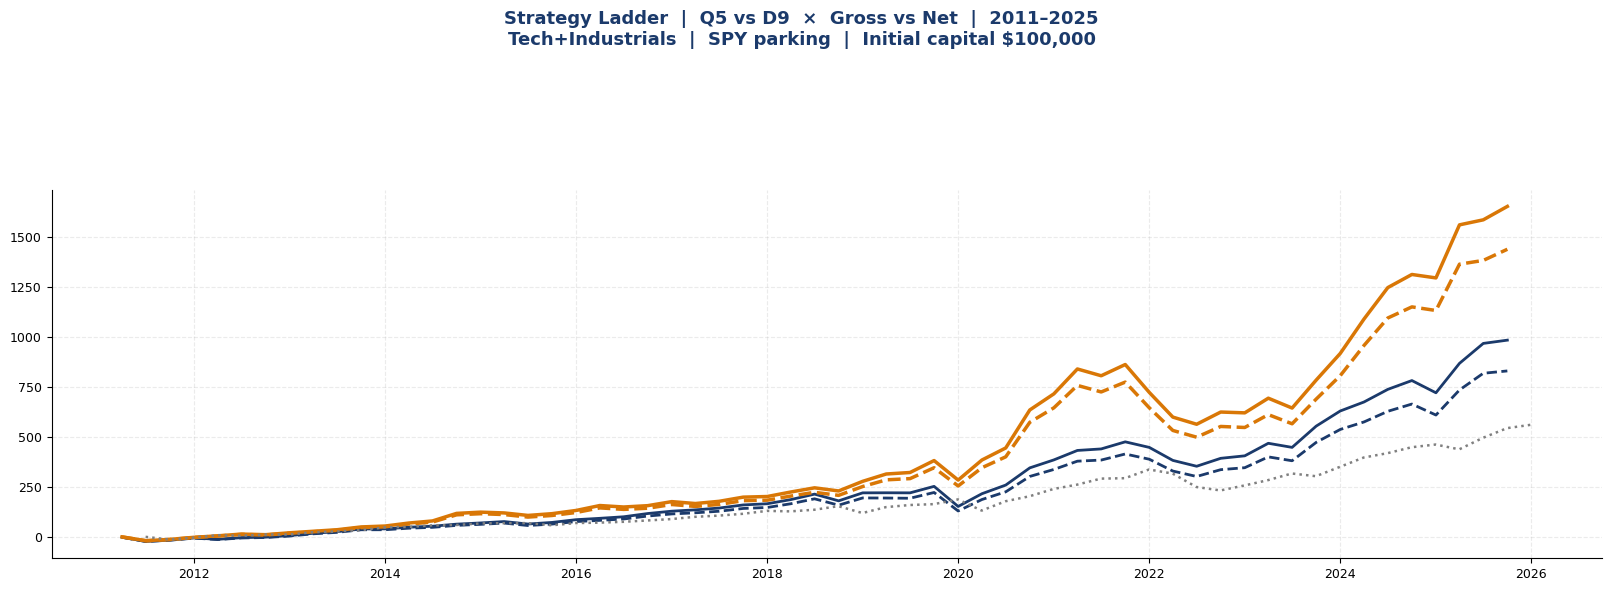

In [132]:
# ══════════════════════════════════════════════════════════════════
# STRATEGY LADDER VISUALS — Q5 vs D9 vs SPY
# ══════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

bts    = [bt_q5_gross, bt_q5_net, bt_d9_gross, bt_d9_net]
colors = [NAVY, NAVY, GOLD, GOLD]
styles = ["-", "--", "-", "--"]
widths = [2.0, 2.0, 2.5, 2.5]

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.38, wspace=0.30)
fig.suptitle(
    "Strategy Ladder  |  Q5 vs D9  ×  Gross vs Net  |  2011–2025\n"
    "Tech+Industrials  |  SPY parking  |  Initial capital $100,000",
    fontweight="bold", fontsize=13, color=NAVY
)

# ── Panel 1: Cumulative return — all strategies ───────────────────
ax1 = fig.add_subplot(gs[0, :])   # full top row

spy_pct = (spy_pv / INITIAL_CAPITAL - 1) * 100

for bt, col, ls, lw in zip(bts, colors, styles, widths):
    pct   = (bt["pv"] / INITIAL_CAPITAL - 1) * 100
    label = (f"{bt['name']}  |  "
             f"${bt['final_value']/1e3:.0f}k  "
             f"Sharpe={bt['sharpe']:.2f}  "
             f"t={bt['t_nw']:+.2f}{sig_stars(bt['p_nw'])}")
    ax1.plot(pct.index, pct.values,
             color=col, linestyle=ls, linewidth=lw, label=label)

ax1.plot(spy_pct.index, spy_pct.values,
         color="grey", linewidth=1.8, linestyle=":",
         label=f"SPY  |  ${spy_final/1e3:.0f}k  Sharpe={spy_sharpe:.2f}")

# Shade D9 net vs SPY
d9_pct    = (bt_d9_net["pv"] / INITIAL_CAPITAL - 1) * 100
spy_align = spy_pct.reindex(bt_d9_net["pv"].index, method="nearest")
ax1.fill_between(bt_d9_net["pv"].index,
                 d9_pct.values, spy_align.values,
                 where=(d9_pct.values >= spy_align.values),
                 alpha=0.06, color=GREEN)
ax1.fill_between(bt_d9_net["pv"].index,
                 d9_pct.values, spy_align.values,
                 where=(d9_pct.values < spy_align.values),
                 alpha=0.06, color=RED)

ax1.axhline(0, color="black", linewidth=0.7)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax1.set_title("Panel 1: Cumulative Return — All Strategies",
              fontweight="bold", color=NAVY)
ax1.set_ylabel("Cumulative Return (%)")
ax1.legend(fontsize=9, loc="upper left",
           framealpha=0.9, ncol=2)


# ── Panel 2: Gross vs Net fee impact ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

for (bt_g, bt_n), col, label in [
    ((bt_q5_gross, bt_q5_net), NAVY, "Q5"),
    ((bt_d9_gross, bt_d9_net), GOLD, "D9"),
]:
    g_pct = (bt_g["pv"] / INITIAL_CAPITAL - 1) * 100
    n_pct = (bt_n["pv"] / INITIAL_CAPITAL - 1) * 100
    ax2.plot(g_pct.index, g_pct.values,
             color=col, linestyle="-", linewidth=2.0,
             label=f"{label} Gross ${bt_g['final_value']/1e3:.0f}k")
    ax2.plot(n_pct.index, n_pct.values,
             color=col, linestyle="--", linewidth=2.0,
             label=f"{label} Net   ${bt_n['final_value']/1e3:.0f}k")
    ax2.fill_between(g_pct.index, g_pct.values, n_pct.values,
                     alpha=0.10, color=col,
                     label=f"{label} fee drag")

ax2.plot(spy_pct.index, spy_pct.values,
         color="grey", linewidth=1.5, linestyle=":",
         label=f"SPY ${spy_final/1e3:.0f}k")
ax2.axhline(0, color="black", linewidth=0.7)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax2.set_title("Panel 2: Fee Drag", fontweight="bold", color=NAVY)
ax2.set_ylabel("Cumulative Return (%)")
ax2.legend(fontsize=7.5)


# ── Panel 3: Drawdown ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

for bt, col, ls, lw in zip(bts, colors, styles, widths):
    dd = (bt["cum"] / bt["cum"].cummax() - 1) * 100
    ax3.plot(dd.index, dd.values,
             color=col, linestyle=ls, linewidth=lw,
             label=f"{bt['name']}  {bt['max_dd']*100:.1f}%")

spy_cum = spy_pv / INITIAL_CAPITAL
spy_dd  = (spy_cum / spy_cum.cummax() - 1) * 100
ax3.plot(spy_dd.index, spy_dd.values,
         color="grey", linewidth=1.5, linestyle=":",
         label=f"SPY  {spy_md*100:.1f}%")
ax3.axhline(0, color="black", linewidth=0.7)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax3.set_title("Panel 3: Drawdown", fontweight="bold", color=NAVY)
ax3.set_ylabel("Drawdown (%)")
ax3.legend(fontsize=7.5)


# ── Panel 4: Metrics bar chart ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])

metrics  = ["Sharpe", "Sortino", "Calmar"]
x        = np.arange(len(metrics))
bar_w    = 0.15
bar_data = [
    (bt_q5_gross, NAVY,  0.9, "Q5 Gross"),
    (bt_q5_net,   NAVY,  0.5, "Q5 Net"),
    (bt_d9_gross, GOLD,  0.9, "D9 Gross"),
    (bt_d9_net,   GOLD,  0.5, "D9 Net"),
]
spy_vals = [spy_sharpe, np.nan, np.nan]

for i, (bt, col, alpha, label) in enumerate(bar_data):
    vals = [bt["sharpe"], bt["sortino"], bt["calmar"]]
    offset = (i - 1.5) * bar_w
    bars = ax4.bar(x + offset, vals, bar_w,
                   color=col, alpha=alpha, label=label,
                   edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax4.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{v:.2f}", ha="center", va="bottom",
                     fontsize=6.5, color="black")

ax4.axhline(spy_sharpe, color="grey", linewidth=1.2,
            linestyle="--", label=f"SPY Sharpe {spy_sharpe:.2f}")
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_title("Panel 4: Risk-Adjusted Metrics",
              fontweight="bold", color=NAVY)
ax4.legend(fontsize=7.5)


# ── Panel 5: Quarterly CAR by strategy ───────────────────────────
ax5 = fig.add_subplot(gs[2, 0])

for bt, col, ls, label in [
    (bt_q5_net, NAVY, "-",  "Q5 Net"),
    (bt_d9_net, GOLD, "--", "D9 Net"),
]:
    qm = bt["qm_car"].dropna()
    ts = qm.index.to_timestamp()
    ax5.plot(ts, qm.values * 100,
             color=col, linestyle=ls, linewidth=1.5,
             alpha=0.7, label=label)
    # Rolling 4-quarter mean
    roll = qm.rolling(4, min_periods=2).mean()
    ax5.plot(roll.index.to_timestamp(), roll.values * 100,
             color=col, linewidth=2.2,
             label=f"{label} 4q roll")

ax5.axhline(0, color="black", linewidth=0.8)
ax5.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax5.set_title("Panel 5: Quarterly CAR + Rolling Mean",
              fontweight="bold", color=NAVY)
ax5.set_ylabel("Excess Return (%)")
ax5.legend(fontsize=7.5)


# ── Panel 6: Sub-period ann. excess ──────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])

periods   = ["2011-15", "2016-20", "2021-25"]
x         = np.arange(len(periods))
bar_w     = 0.18

for i, (bt, col, alpha, label) in enumerate(bar_data):
    vals   = []
    p_vals = []
    for p_lbl in periods:
        exc, t_, p_, n_ = bt["sub_periods"].get(
            p_lbl, (np.nan, np.nan, np.nan, 0)
        )
        vals.append(exc if not np.isnan(exc) else 0)
        p_vals.append(p_)

    offset = (i - 1.5) * bar_w
    bars   = ax6.bar(x + offset, vals, bar_w,
                     color=col, alpha=alpha, label=label,
                     edgecolor="white", linewidth=0.5)
    for bar, v, p_ in zip(bars, vals, p_vals):
        if v != 0:
            ax6.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + (0.2 if v >= 0 else -0.5),
                     sig_stars(p_),
                     ha="center", fontsize=7, color="black")

ax6.axhline(0, color="black", linewidth=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(periods)
ax6.set_title("Panel 6: Sub-period Ann. Excess Return",
              fontweight="bold", color=NAVY)
ax6.set_ylabel("Ann. Excess Return (%)")
ax6.legend(fontsize=7.5)


# ── Panel 7: Signal t-stats ───────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])

strategy_names = ["Q5\nGross", "Q5\nNet", "D9\nGross", "D9\nNet"]
t_vals  = [bt["t_nw"]     for bt in bts]
ts_vals = [bt["t_stress"] for bt in bts]
x       = np.arange(len(strategy_names))
bar_w   = 0.30

bars1 = ax7.bar(x - bar_w/2, t_vals,  bar_w,
                color=[NAVY, NAVY, GOLD, GOLD],
                alpha=[0.9, 0.5, 0.9, 0.5],
                label="NW t-stat", edgecolor="white")
bars2 = ax7.bar(x + bar_w/2, ts_vals, bar_w,
                color=[NAVY, NAVY, GOLD, GOLD],
                alpha=[0.5, 0.3, 0.5, 0.3],
                label="Stress t", edgecolor="white",
                hatch="///")

for bar, t_, bt in zip(bars1, t_vals, bts):
    ax7.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{t_:+.2f}{sig_stars(bt['p_nw'])}",
             ha="center", fontsize=7.5, fontweight="bold")

ax7.axhline(1.96,  color=RED,   linewidth=1.2, linestyle="--",
            label="5% threshold (1.96)")
ax7.axhline(1.645, color=GOLD,  linewidth=1.0, linestyle=":",
            label="10% threshold (1.645)")
ax7.axhline(0,     color="black", linewidth=0.7)
ax7.set_xticks(x)
ax7.set_xticklabels(strategy_names)
ax7.set_title("Panel 7: T-Statistics (NW vs Stress)",
              fontweight="bold", color=NAVY)
ax7.set_ylabel("t-statistic")
ax7.legend(fontsize=7.5)


plt.savefig("pead_strategy_ladder.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_strategy_ladder.png")

  STATISTICAL SIGNIFICANCE — Q5 NET STRATEGY
  n=60 signal quarters  |  Mean CAR=+0.867%/qtr  |  Ann=+3.47%

─────────────────────────────────────────────────────────────────
  PRECONDITION: DISTRIBUTION CHECK
─────────────────────────────────────────────────────────────────

  Metric                             Q5          D9
  ─────────────────────────  ──────────  ──────────
  n (signal quarters)                60          60
  Mean CAR/qtr                  +0.867%     +1.488%
  Std dev                        2.089%      5.131%
  Skewness                       +0.539      +1.183
  Excess kurtosis                +1.347      +2.635
  Shapiro-Wilk p                 0.1775      0.0008
  Normal?                         ✓ yes        ✗ no

─────────────────────────────────────────────────────────────────
  FIVE SIGNIFICANCE TESTS  (H0: mean CAR = 0)
─────────────────────────────────────────────────────────────────

  Test                                      Q5          D9    Q5 sig    D9 

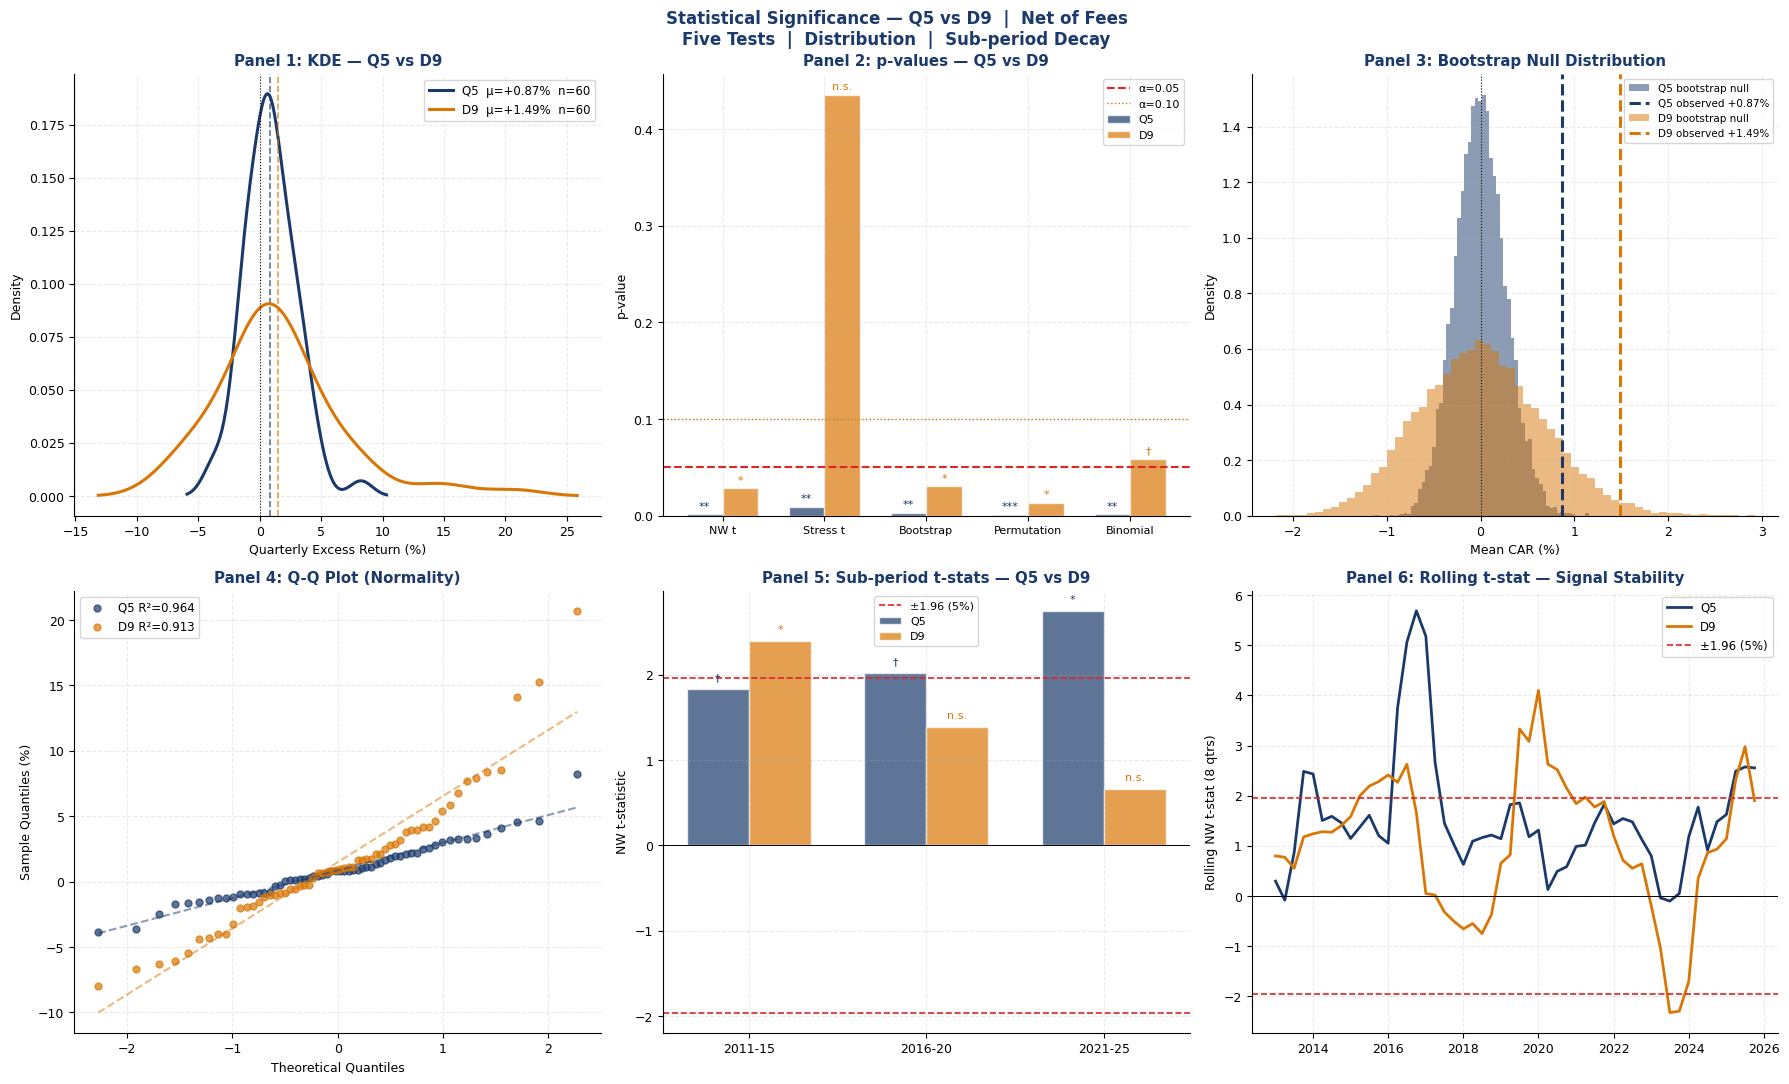

Saved: pead_q5_significance.png

  SUMMARY — Q5 vs D9

  Metric                                    Q5            D9
  ──────────────────────────────  ────────────  ────────────
  Signals/yr                               123            12
  Mean CAR/qtr                         +0.867%       +1.488%
  Ann. excess                           +3.47%        +5.95%
  NW t-stat                             +3.368        +2.247
  NW p-value                            0.0013        0.0285
  Stress t                              +2.704        +0.785
  Stress p                              0.0091        0.4357
  Bootstrap p                           0.0030        0.0304
  Permutation p                         0.0009        0.0133
  Binomial p                            0.0013        0.0587
  Tests sig @ 5%                             5             3
  95% CI excludes 0                          ✓             ✓
  Sharpe (portfolio)                     0.682         0.819
  Final value                 

In [135]:
# ══════════════════════════════════════════════════════════════════
# STATISTICAL SIGNIFICANCE TESTS — Q5 STRATEGY
# Mirror of D9 analysis: 5 tests + bootstrap + permutation
# ══════════════════════════════════════════════════════════════════
from scipy.stats import binomtest, shapiro

# ── Extract pure signal CAR series ───────────────────────────────
def extract_car(bt, sig_df):
    car_list, qtr_list = [], []
    for q in sorted(sig_df["Quarter"].dropna().unique()):
        grp = sig_df[sig_df["Quarter"] == q].dropna(subset=["R30","SPY_R30"])
        if len(grp) == 0:
            continue
        notional = INITIAL_CAPITAL / len(grp)
        cost     = np.mean([
            round_trip_cost(notional, ticker_px.get(r["Ticker"], 100.0))
            for _, r in grp.iterrows()
        ])
        r30_net = grp["R30"].mean() - cost
        spy_r30 = grp["SPY_R30"].mean()
        car_list.append(r30_net - spy_r30)
        qtr_list.append(q)
    return np.array(car_list), np.array(qtr_list)

# extract_car is hardcoded to sig_q5 — fix:
car_q5, qtrs_q5 = extract_car(bt_q5_net, sig_q5)
car_d9, qtrs_d9 = extract_car(bt_d9_net, sig_d9)
T_q5 = len(car_q5)
T_d9 = len(car_d9)
rng  = np.random.default_rng(BOOT_SEED)

print("=" * 65)
print("  STATISTICAL SIGNIFICANCE — Q5 NET STRATEGY")
print(f"  n={T_q5} signal quarters  |  "
      f"Mean CAR={car_q5.mean()*100:+.3f}%/qtr  |  "
      f"Ann={car_q5.mean()*400:+.2f}%")
print("=" * 65)


# ══════════════════════════════════════════════════════════════════
# TEST 1: NORMALITY (precondition check)
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*65}")
print("  PRECONDITION: DISTRIBUTION CHECK")
print(f"{'─'*65}")

skew_q5        = scipy_stats.skew(car_q5)
kurt_q5        = scipy_stats.kurtosis(car_q5)
_, p_sw_q5     = shapiro(car_q5)
_, p_sw_d9     = shapiro(car_d9)

print(f"\n  {'Metric':<25}  {'Q5':>10}  {'D9':>10}")
print(f"  {'─'*25}  {'─'*10}  {'─'*10}")
print(f"  {'n (signal quarters)':<25}  {T_q5:>10}  {T_d9:>10}")
print(f"  {'Mean CAR/qtr':<25}  {car_q5.mean()*100:>+9.3f}%  "
      f"{car_d9.mean()*100:>+9.3f}%")
print(f"  {'Std dev':<25}  {car_q5.std()*100:>9.3f}%  "
      f"{car_d9.std()*100:>9.3f}%")
print(f"  {'Skewness':<25}  {skew_q5:>+10.3f}  "
      f"{scipy_stats.skew(car_d9):>+10.3f}")
print(f"  {'Excess kurtosis':<25}  {kurt_q5:>+10.3f}  "
      f"{scipy_stats.kurtosis(car_d9):>+10.3f}")
print(f"  {'Shapiro-Wilk p':<25}  {p_sw_q5:>10.4f}  {p_sw_d9:>10.4f}")
print(f"  {'Normal?':<25}  "
      f"{'✓ yes' if p_sw_q5 > 0.05 else '✗ no':>10}  "
      f"{'✓ yes' if p_sw_d9 > 0.05 else '✗ no':>10}")


# ══════════════════════════════════════════════════════════════════
# FIVE SIGNIFICANCE TESTS
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*65}")
print("  FIVE SIGNIFICANCE TESTS  (H0: mean CAR = 0)")
print(f"{'─'*65}")

# 1. NW t-test
se_nw_q5 = nw_se(car_q5)
t_nw_q5  = car_q5.mean() / se_nw_q5
p_nw_q5  = 2 * (1 - scipy_stats.t.cdf(abs(t_nw_q5), df=T_q5-1))

# 2. Stress t (drop 5 best)
top5_q5  = np.argsort(car_q5)[-5:]
car_c_q5 = np.delete(car_q5, top5_q5)
se_c_q5  = nw_se(car_c_q5)
t_c_q5   = car_c_q5.mean() / se_c_q5 if se_c_q5 else np.nan
p_c_q5   = 2 * (1 - scipy_stats.t.cdf(abs(t_c_q5),
                                        df=len(car_c_q5)-1))

# 3. Bootstrap (null-shifted)
obs_mean_q5  = car_q5.mean()
boot_q5      = np.array([
    rng.choice(car_q5, size=T_q5, replace=True).mean()
    for _ in range(N_BOOT)
])
boot_null_q5 = boot_q5 - boot_q5.mean()
p_boot_q5    = 2 * min((boot_null_q5 >= obs_mean_q5).mean(),
                        (boot_null_q5 <= obs_mean_q5).mean())
ci_lo_q5     = np.percentile(boot_q5, 2.5)
ci_hi_q5     = np.percentile(boot_q5, 97.5)
boot_se_q5   = boot_q5.std()

# 4. Permutation (sign-flip)
perm_q5  = np.array([
    (car_q5 * rng.choice([-1,1], size=T_q5)).mean()
    for _ in range(N_BOOT)
])
p_perm_q5 = (perm_q5 >= obs_mean_q5).mean()

# 5. Binomial
n_wins_q5  = (car_q5 > 0).sum()
p_binom_q5 = binomtest(int(n_wins_q5), T_q5,
                        p=0.5, alternative="greater").pvalue

# Print results vs D9
print(f"\n  {'Test':<32}  {'Q5':>10}  {'D9':>10}  {'Q5 sig':>8}  {'D9 sig':>8}")
print(f"  {'─'*32}  {'─'*10}  {'─'*10}  {'─'*8}  {'─'*8}")

d9_stats = [
    bt_d9_net["p_nw"], bt_d9_net["p_stress"],
    bt_d9_net["p_boot"], bt_d9_net["p_perm"], bt_d9_net["p_binom"]
]
q5_stats = [p_nw_q5, p_c_q5, p_boot_q5, p_perm_q5, p_binom_q5]
q5_tstats = [t_nw_q5, t_c_q5, None, None, None]
d9_tstats = [bt_d9_net["t_nw"], bt_d9_net["t_stress"], None, None, None]

test_names = [
    "NW t-test",
    "Stress t (drop 5 best qtrs)",
    "Bootstrap (null-shifted)",
    "Permutation (sign-flip)",
    "Binomial (beat SPY > 50%?)",
]

for name, p_q5, p_d9, t_q5_, t_d9_ in zip(
    test_names, q5_stats, d9_stats, q5_tstats, d9_tstats
):
    note_q5 = f"t={t_q5_:+.2f}" if t_q5_ is not None else ""
    print(f"  {name:<32}  {p_q5:>10.4f}  {p_d9:>10.4f}  "
          f"{sig_stars(p_q5):>8}  {sig_stars(p_d9):>8}"
          + (f"  {note_q5}" if note_q5 else ""))

n_sig_q5  = sum(p < 0.05 for p in q5_stats if not np.isnan(p))
n_sig_d9  = sum(p < 0.05 for p in d9_stats if not np.isnan(p))
n_sig10_q5 = sum(p < 0.10 for p in q5_stats if not np.isnan(p))

print(f"\n  Significant at 5%:  Q5={n_sig_q5}/5   D9={n_sig_d9}/5")
print(f"  Significant at 10%: Q5={n_sig10_q5}/5")
print(f"\n  95% CI (Q5): [{ci_lo_q5*100:+.3f}%, {ci_hi_q5*100:+.3f}%]  "
      f"{'excludes zero ✓' if ci_lo_q5 > 0 else 'includes zero ✗'}")
print(f"  95% CI (D9): [{bt_d9_net['ci_lo']*100:+.3f}%, "
      f"{bt_d9_net['ci_hi']*100:+.3f}%]  "
      f"{'excludes zero ✓' if bt_d9_net['ci_lo'] > 0 else 'includes zero ✗'}")


# ══════════════════════════════════════════════════════════════════
# SUB-PERIOD DECAY
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*65}")
print("  SUB-PERIOD BREAKDOWN  (pure signal window)")
print(f"{'─'*65}")
print(f"\n  {'Period':<10}  {'n':>4}  {'Q5 Ann Exc':>12}  "
      f"{'Q5 t':>8}  {'':>6}  {'D9 Ann Exc':>12}  {'D9 t':>8}  {''}")
print(f"  {'─'*10}  {'─'*4}  {'─'*12}  {'─'*8}  {'─'*6}  "
      f"{'─'*12}  {'─'*8}  {'─'*6}")

for lbl, y1, y2 in [("2011-15",2011,2015),
                     ("2016-20",2016,2020),
                     ("2021-25",2021,2025)]:
    # Q5
    sub_q5 = np.array([
        car_q5[i] for i, q in enumerate(qtrs_q5)
        if y1 <= q.year <= y2
    ])
    if len(sub_q5) >= 4:
        se_  = nw_se(sub_q5)
        t_q5_ = sub_q5.mean() / se_ if se_ else np.nan
        p_q5_ = 2*(1-scipy_stats.t.cdf(abs(t_q5_), df=len(sub_q5)-1))
        q5_str = (f"{sub_q5.mean()*400:>+10.2f}%  "
                  f"{t_q5_:>+8.2f}  {sig_stars(p_q5_):>6}")
        n_q5   = len(sub_q5)
    else:
        q5_str = f"{'—':>12}  {'—':>8}  {'—':>6}"
        n_q5   = 0

    # D9
    exc_d9, t_d9_, p_d9_, n_d9 = bt_d9_net["sub_periods"].get(
        lbl, (np.nan, np.nan, np.nan, 0)
    )
    if not np.isnan(exc_d9):
        d9_str = (f"{exc_d9:>+10.2f}%  "
                  f"{t_d9_:>+8.2f}  {sig_stars(p_d9_):>6}")
    else:
        d9_str = f"{'—':>12}  {'—':>8}  {'—':>6}"

    print(f"  {lbl:<10}  {n_q5:>4}  {q5_str}  {d9_str}")


# ══════════════════════════════════════════════════════════════════
# POWER ANALYSIS
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*65}")
print("  POWER ANALYSIS")
print(f"{'─'*65}")

for label, car_, T_ in [("Q5", car_q5, T_q5), ("D9", car_d9, T_d9)]:
    snr    = car_.mean() / car_.std()
    power  = 1 - scipy_stats.t.cdf(
        scipy_stats.t.ppf(0.95, df=T_-1) - snr * np.sqrt(T_),
        df=T_-1
    )
    n_80   = int(np.ceil((1.28 + 0.84)**2 / snr**2))
    n_90   = int(np.ceil((1.645 + 1.282)**2 / snr**2))
    print(f"\n  {label}:")
    print(f"    SNR (mean/std)    : {snr:.3f}")
    print(f"    Current power     : {power:.1%}  (n={T_})")
    print(f"    n for 80% power   : {n_80} qtrs = {n_80//4:.0f} yrs")
    print(f"    n for 90% power   : {n_90} qtrs = {n_90//4:.0f} yrs")


# ══════════════════════════════════════════════════════════════════
# VISUAL
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Statistical Significance — Q5 vs D9  |  Net of Fees\n"
    "Five Tests  |  Distribution  |  Sub-period Decay",
    fontweight="bold", fontsize=12, color=NAVY
)

# ── Panel 1: Distribution comparison Q5 vs D9 ────────────────────
ax = axes[0, 0]
for car_, col, label in [
    (car_q5, NAVY, f"Q5  μ={car_q5.mean()*100:+.2f}%  n={T_q5}"),
    (car_d9, GOLD, f"D9  μ={car_d9.mean()*100:+.2f}%  n={T_d9}"),
]:
    x_r = np.linspace(car_.min()-car_.std(), car_.max()+car_.std(), 200)
    kde = scipy_stats.gaussian_kde(car_)
    ax.plot(x_r*100, kde(x_r)/100, color=col, linewidth=2.2, label=label)
    ax.axvline(car_.mean()*100, color=col, linewidth=1.2,
               linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Quarterly Excess Return (%)")
ax.set_ylabel("Density")
ax.set_title("Panel 1: KDE — Q5 vs D9", fontweight="bold", color=NAVY)
ax.legend(fontsize=8.5)


# ── Panel 2: p-value comparison bar ──────────────────────────────
ax = axes[0, 1]
test_lbls = ["NW t", "Stress t", "Bootstrap", "Permutation", "Binomial"]
x         = np.arange(len(test_lbls))
bar_w     = 0.35

ax.bar(x - bar_w/2, q5_stats, bar_w, color=NAVY,
       alpha=0.7, label="Q5", edgecolor="white")
ax.bar(x + bar_w/2, d9_stats, bar_w, color=GOLD,
       alpha=0.7, label="D9", edgecolor="white")
ax.axhline(0.05, color=RED,   linewidth=1.5, linestyle="--",
           label="α=0.05")
ax.axhline(0.10, color=GOLD,  linewidth=1.0, linestyle=":",
           label="α=0.10")
ax.set_xticks(x)
ax.set_xticklabels(test_lbls, fontsize=8)
ax.set_ylabel("p-value")
ax.set_title("Panel 2: p-values — Q5 vs D9",
             fontweight="bold", color=NAVY)
ax.legend(fontsize=8)

for i, (pq, pd_) in enumerate(zip(q5_stats, d9_stats)):
    ax.text(i - bar_w/2, pq + 0.005, sig_stars(pq),
            ha="center", fontsize=8, color=NAVY)
    ax.text(i + bar_w/2, pd_ + 0.005, sig_stars(pd_),
            ha="center", fontsize=8, color=GOLD)


# ── Panel 3: Bootstrap null distribution ─────────────────────────
ax = axes[0, 2]
for car_, boot_, obs_, col, label in [
    (car_q5, boot_null_q5, obs_mean_q5, NAVY, "Q5"),
    (car_d9,
     np.array([rng.choice(car_d9, size=T_d9, replace=True).mean()
               for _ in range(N_BOOT)]) -
     np.array([rng.choice(car_d9, size=T_d9, replace=True).mean()
               for _ in range(N_BOOT)]).mean(),
     car_d9.mean(), GOLD, "D9"),
]:
    ax.hist(boot_*100, bins=60, density=True, alpha=0.5,
            color=col, label=f"{label} bootstrap null")
    ax.axvline(obs_*100, color=col, linewidth=2.2, linestyle="--",
               label=f"{label} observed {obs_*100:+.2f}%")
ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Mean CAR (%)")
ax.set_ylabel("Density")
ax.set_title("Panel 3: Bootstrap Null Distribution",
             fontweight="bold", color=NAVY)
ax.legend(fontsize=7.5)


# ── Panel 4: Q-Q plots ────────────────────────────────────────────
ax = axes[1, 0]
for car_, col, label in [
    (car_q5, NAVY, "Q5"),
    (car_d9, GOLD, "D9"),
]:
    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(
        car_, dist="norm"
    )
    ax.scatter(osm, osr*100, color=col, s=25, alpha=0.7,
               label=f"{label} R²={r**2:.3f}")
    ax.plot(osm, (slope*np.array(osm)+intercept)*100,
            color=col, linewidth=1.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles (%)")
ax.set_title("Panel 4: Q-Q Plot (Normality)",
             fontweight="bold", color=NAVY)
ax.legend(fontsize=8.5)


# ── Panel 5: Sub-period t-stats ───────────────────────────────────
ax = axes[1, 1]
periods   = ["2011-15", "2016-20", "2021-25"]
x         = np.arange(len(periods))
bar_w     = 0.35

q5_t_sub, d9_t_sub, q5_p_sub, d9_p_sub = [], [], [], []
for lbl, y1, y2 in [("2011-15",2011,2015),
                     ("2016-20",2016,2020),
                     ("2021-25",2021,2025)]:
    sub = np.array([
        car_q5[i] for i, q in enumerate(qtrs_q5)
        if y1 <= q.year <= y2
    ])
    if len(sub) >= 4:
        se_ = nw_se(sub)
        t_  = sub.mean()/se_ if se_ else 0
        p_  = 2*(1-scipy_stats.t.cdf(abs(t_), df=len(sub)-1))
    else:
        t_, p_ = 0, 1.0
    q5_t_sub.append(t_); q5_p_sub.append(p_)

    exc, t_d9_, p_d9_, _ = bt_d9_net["sub_periods"].get(
        lbl, (np.nan, 0, 1.0, 0)
    )
    d9_t_sub.append(t_d9_ if not np.isnan(t_d9_) else 0)
    d9_p_sub.append(p_d9_ if not np.isnan(p_d9_) else 1.0)

ax.bar(x - bar_w/2, q5_t_sub, bar_w, color=NAVY,
       alpha=0.7, label="Q5", edgecolor="white")
ax.bar(x + bar_w/2, d9_t_sub, bar_w, color=GOLD,
       alpha=0.7, label="D9", edgecolor="white")
ax.axhline( 1.96,  color=RED,  linewidth=1.2, linestyle="--",
            label="±1.96 (5%)")
ax.axhline(-1.96,  color=RED,  linewidth=1.2, linestyle="--")
ax.axhline(0,      color="black", linewidth=0.7)

for i, (tq, pq, td, pd_) in enumerate(
    zip(q5_t_sub, q5_p_sub, d9_t_sub, d9_p_sub)
):
    ax.text(i-bar_w/2, tq+(0.1 if tq>=0 else -0.3),
            sig_stars(pq), ha="center", fontsize=8, color=NAVY)
    ax.text(i+bar_w/2, td+(0.1 if td>=0 else -0.3),
            sig_stars(pd_), ha="center", fontsize=8, color=GOLD)

ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.set_ylabel("NW t-statistic")
ax.set_title("Panel 5: Sub-period t-stats — Q5 vs D9",
             fontweight="bold", color=NAVY)
ax.legend(fontsize=8)


# ── Panel 6: Rolling 8-qtr t-stat ────────────────────────────────
ax = axes[1, 2]
for car_, qtrs_, col, label in [
    (car_q5, qtrs_q5, NAVY, "Q5"),
    (car_d9, qtrs_d9, GOLD, "D9"),
]:
    roll_t, roll_idx = [], []
    for i in range(8, len(car_)):
        window = car_[i-8:i]
        se_    = nw_se(window)
        t_     = window.mean()/se_ if se_ else np.nan
        roll_t.append(t_)
        roll_idx.append(qtrs_[i].to_timestamp())

    ax.plot(roll_idx, roll_t, color=col, linewidth=2.0, label=label)

ax.axhline( 1.96, color=RED,   linewidth=1.2, linestyle="--",
            label="±1.96 (5%)")
ax.axhline(-1.96, color=RED,   linewidth=1.2, linestyle="--")
ax.axhline( 0,    color="black", linewidth=0.7)
ax.fill_between(roll_idx,  1.96,
                [max(t, 1.96) for t in roll_t],
                alpha=0.0)
ax.set_ylabel("Rolling NW t-stat (8 qtrs)")
ax.set_title("Panel 6: Rolling t-stat — Signal Stability",
             fontweight="bold", color=NAVY)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig("pead_q5_significance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pead_q5_significance.png")


# ── Final summary ─────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  SUMMARY — Q5 vs D9")
print(f"{'='*65}")
print(f"""
  {'Metric':<30}  {'Q5':>12}  {'D9':>12}
  {'─'*30}  {'─'*12}  {'─'*12}
  {'Signals/yr':<30}  {len(sig_q5)//14:>12}  {len(sig_d9)//14:>12}
  {'Mean CAR/qtr':<30}  {car_q5.mean()*100:>+11.3f}%  {car_d9.mean()*100:>+11.3f}%
  {'Ann. excess':<30}  {car_q5.mean()*400:>+11.2f}%  {car_d9.mean()*400:>+11.2f}%
  {'NW t-stat':<30}  {t_nw_q5:>+12.3f}  {bt_d9_net['t_nw']:>+12.3f}
  {'NW p-value':<30}  {p_nw_q5:>12.4f}  {bt_d9_net['p_nw']:>12.4f}
  {'Stress t':<30}  {t_c_q5:>+12.3f}  {bt_d9_net['t_stress']:>+12.3f}
  {'Stress p':<30}  {p_c_q5:>12.4f}  {bt_d9_net['p_stress']:>12.4f}
  {'Bootstrap p':<30}  {p_boot_q5:>12.4f}  {bt_d9_net['p_boot']:>12.4f}
  {'Permutation p':<30}  {p_perm_q5:>12.4f}  {bt_d9_net['p_perm']:>12.4f}
  {'Binomial p':<30}  {p_binom_q5:>12.4f}  {bt_d9_net['p_binom']:>12.4f}
  {'Tests sig @ 5%':<30}  {n_sig_q5:>12}  {n_sig_d9:>12}
  {'95% CI excludes 0':<30}  {'✓' if ci_lo_q5>0 else '✗':>12}  {'✓' if bt_d9_net['ci_lo']>0 else '✗':>12}
  {'Sharpe (portfolio)':<30}  {bt_q5_net['sharpe']:>12.3f}  {bt_d9_net['sharpe']:>12.3f}
  {'Final value':<30}  ${bt_q5_net['final_value']:>11,.0f}  ${bt_d9_net['final_value']:>11,.0f}
""")

In [136]:
# If the consistency story is true:
# 1. Rolling std of quarterly CARs should be DECREASING over time
# 2. Hit rate (% quarters positive) should be INCREASING
# 3. The signal should be stronger in stocks with MORE analyst coverage
#    (opposite of classic PEAD where thin coverage = more drift)

for lbl, y1, y2 in [("2011-15",2011,2015),
                     ("2016-20",2016,2020),
                     ("2021-25",2021,2025)]:
    sub = np.array([
        car_q5[i] for i, q in enumerate(qtrs_q5)
        if y1 <= q.year <= y2
    ])
    hit  = (sub > 0).mean()
    print(f"{lbl}  std={sub.std()*100:.2f}%  "
          f"hit={hit:.0%}  mean={sub.mean()*100:+.2f}%  "
          f"t={sub.mean()/nw_se(sub):+.2f}")

2011-15  std=1.95%  hit=75%  mean=+0.71%  t=+1.83
2016-20  std=2.53%  hit=70%  mean=+1.16%  t=+2.02
2021-25  std=1.66%  hit=65%  mean=+0.73%  t=+2.75


In [137]:
# The question is whether the compressed 2021-25 distribution
# is stable or still converging toward zero.
# If std keeps falling and mean holds, t-stat keeps rising
# but the actual $ edge per trade is shrinking.
# Compute edge per signal to see if it's worth trading:

for lbl, y1, y2 in [("2011-15",2011,2015),
                     ("2016-20",2016,2020),
                     ("2021-25",2021,2025)]:
    sub = np.array([
        car_q5[i] for i, q in enumerate(qtrs_q5)
        if y1 <= q.year <= y2
    ])
    n_sigs = len(sig_q5[
        sig_q5["Date"].dt.year.between(y1, y2)
    ])
    edge_per_signal = sub.mean() / (n_sigs / len(sub))
    print(f"{lbl}  mean/qtr={sub.mean()*100:+.2f}%  "
          f"signals/qtr={n_sigs/len(sub):.0f}  "
          f"edge/signal={edge_per_signal*100:+.3f}%")

2011-15  mean/qtr=+0.71%  signals/qtr=27  edge/signal=+0.027%
2016-20  mean/qtr=+1.16%  signals/qtr=29  edge/signal=+0.040%
2021-25  mean/qtr=+0.73%  signals/qtr=30  edge/signal=+0.024%
